# IEEE-CIS Fraud Detection: 비용 민감형 사기탐지 모델 개발
## Day 3. Feature Engineering

**목표**
Day 1~2에서 확정된 핵심 신호 변수들을 바탕으로, 모델 입력에 사용할 최종 파생변수 세트를 설계합니다.

**Day 1~2에서 확정된 사항 정리**

| 구분 | 내용 |
|---|---|
| 핵심 변수(강한 신호) | ProductCD, addr_missing, has_identity, C4·C8·C10·C12, D1 |
| 중간 신호 변수 | card6, V_group9·10·11·12, C7·C5·C9·C2·C13·C1·C11, amt_zscore |
| 약한/무신호 변수 | card4, C3, V_group1·2·3, TransactionAmt 원본 |
| UID 설계 확정 | card1+card2+addr1 (D1 제외) |
| 클래스 불균형 처리 | class_weight/scale_pos_weight 우선 |

**오늘(Day 3) 수행할 작업**
1. UID 정식 설계 및 매칭 품질 검증 (간이 버전 → 정식 버전으로)
2. UID 기준 사용자 단위 집계 변수 (거래 빈도, 평균/표준편차 금액, 최근 거래 간격)
3. 금액 편차 변수 정식화 (amt_zscore, 결측 처리 방식 확정)
4. 그룹 결측 플래그 변수 일괄 생성 (V_group9~12 등 유의했던 그룹 중심)
5. 시간 파생 변수 (TransactionDT → hour, day, weekday, month)
6. V컬럼 차원축소 (그룹별 대표변수 또는 PCA)
7. 최종 변수 세트 정리 및 저장

### 1. Day 2 산출물 불러오기

In [1]:
import pandas as pd
import numpy as np
import os

pd.set_option('display.max_columns', 100)

df = pd.read_parquet("../data/processed/day2_merged.parquet")
print("shape:", df.shape)
print("isFraud 비율:\n", df['isFraud'].value_counts(normalize=True))

shape: (590540, 461)
isFraud 비율:
 isFraud
0    0.96501
1    0.03499
Name: proportion, dtype: float64


### 2. UID 정식 설계

Day 2에서 D1을 제외한 card1+card2+addr1 조합(UID_v2)이 그룹화에 더 적합함을 확인했습니다. 이를 정식 UID로 채택하고, 매칭 품질(그룹 크기 분포, 신뢰도)을 다시 한번 점검합니다.

**설계 결정**: UID = card1 + card2 + addr1
- D1 제외 이유: 거래마다 값이 달라지는 timedelta 변수라 그룹화에 부적합 (Day 2에서 확인)
- card3, card4, card5, card6, addr2 제외 이유: card3·card5는 소수 값에 집중(분산 작음), card4·card6은 통계검정에서 약한 신호, addr2는 88%가 단일값(87.0)에 쏠려 식별력이 낮음

In [2]:
# UID_v2를 정식 UID로 채택 (Day 2에서 이미 생성된 컬럼 재사용)
df['UID'] = df['UID_v2']

uid_counts = df['UID'].value_counts()
print(f"고유 UID 개수: {df['UID'].nunique():,}")
print(f"UID당 평균 거래 건수: {len(df) / df['UID'].nunique():.2f}")
print(f"\nUID별 거래 건수 분포:\n{uid_counts.describe()}")
print(f"\n거래 1건뿐인 UID 비율(그룹 기준): {(uid_counts == 1).sum() / len(uid_counts):.1%}")
print(f"거래 1건뿐인 거래 비율(행 기준): {(uid_counts == 1).sum() / len(df):.1%}")

고유 UID 개수: 41,672
UID당 평균 거래 건수: 14.17

UID별 거래 건수 분포:
count    41672.000000
mean        14.171146
std        103.207016
min          1.000000
25%          1.000000
50%          2.000000
75%          7.000000
max       9900.000000
Name: count, dtype: float64

거래 1건뿐인 UID 비율(그룹 기준): 40.3%
거래 1건뿐인 거래 비율(행 기준): 2.8%


### 3. UID 신뢰도 민감도 분석

UID는 "추정" 식별자이며 완벽한 사용자 매칭을 보장하지 않습니다(2.4절 한계 명시). card1, card2, addr1 중 일부를 제외했을 때 그룹 수가 얼마나 달라지는지 확인하여, 조합의 안정성을 점검합니다.

In [3]:
uid_variants = {
    'card1+card2+addr1 (채택)': df['card1'].astype(str) + '_' + df['card2'].astype(str) + '_' + df['addr1'].astype(str),
    'card1+addr1만': df['card1'].astype(str) + '_' + df['addr1'].astype(str),
    'card1+card2만': df['card1'].astype(str) + '_' + df['card2'].astype(str),
    'card1만': df['card1'].astype(str),
}

print("UID 조합별 비교:")
for name, uid_series in uid_variants.items():
    n_unique = uid_series.nunique()
    counts = uid_series.value_counts()
    single_ratio = (counts == 1).sum() / len(counts)
    print(f"  {name}: 고유 그룹 {n_unique:,}개, 1건짜리 그룹 비율(그룹기준) {single_ratio:.1%}")

UID 조합별 비교:
  card1+card2+addr1 (채택): 고유 그룹 41,672개, 1건짜리 그룹 비율(그룹기준) 40.3%
  card1+addr1만: 고유 그룹 39,974개, 1건짜리 그룹 비율(그룹기준) 39.4%
  card1+card2만: 고유 그룹 14,524개, 1건짜리 그룹 비율(그룹기준) 27.4%
  card1만: 고유 그룹 13,553개, 1건짜리 그룹 비율(그룹기준) 25.4%


In [5]:
# card1 값별로 거래금액의 변동성(CV: 표준편차/평균)을 확인
# 개별 카드라면 한 사람의 소비 패턴이라 CV가 비교적 작아야 하고,
# 카드 종류(많은 사람이 공유)라면 사람마다 제각각이라 CV가 커야 함

card1_groups = df.groupby('card1', observed=True)['TransactionAmt'].agg(['mean', 'std', 'count'])
card1_groups = card1_groups[card1_groups['count'] >= 10]  # 표본 10건 이상인 그룹만
card1_groups['cv'] = card1_groups['std'] / card1_groups['mean']

print(f"거래 10건 이상인 card1 그룹 수: {len(card1_groups)}")
print(f"\ncard1 그룹별 변동계수(CV) 분포:")
print(card1_groups['cv'].describe())

# 비교 대상: 만약 정말 무작위로 묶인 그룹이라면 어느 정도 CV가 나올지
# 전체 데이터에서 무작위로 같은 크기만큼 뽑아 비교
import random
random.seed(42)
sample_groups_cv = []
for size in card1_groups['count'].sample(min(100, len(card1_groups)), random_state=42):
    random_sample = df['TransactionAmt'].sample(int(size), random_state=42)
    sample_groups_cv.append(random_sample.std() / random_sample.mean())

print(f"\n[비교] 무작위 샘플 그룹의 CV 평균: {np.mean(sample_groups_cv):.3f}")
print(f"[실제] card1 그룹의 CV 평균: {card1_groups['cv'].mean():.3f}")

거래 10건 이상인 card1 그룹 수: 4298

card1 그룹별 변동계수(CV) 분포:
count    4298.000000
mean        0.967247
std         0.469226
min         0.000000
25%         0.623614
50%         0.869423
75%         1.235233
max         3.642629
Name: cv, dtype: float64

[비교] 무작위 샘플 그룹의 CV 평균: 1.251
[실제] card1 그룹의 CV 평균: 0.967


### UID 식별자 성격 검증 결과 요약

- card1~card6의 정확한 의미는 Kaggle 공식 설명상 "카드 타입·카테고리·발급은행·국가 등"으로만 명시되어 있으며, 각 컬럼이 개별 카드 식별자인지 카드 종류 분류인지는 공식적으로 확인되지 않음
- card1 그룹(거래 10건 이상) 내 거래금액 변동계수(CV) 평균은 0.967로, 무작위 샘플 그룹의 CV(1.251)보다는 낮으나 그 차이가 크지 않은 것으로 확인됨
- 이는 card1이 완전히 무작위적인 다수 공유 코드(카드 종류)도 아니고, 완전한 개인 식별자도 아닌 중간 성격의 변수일 가능성을 시사함
- 따라서 UID(card1+card2+addr1)는 "추정 식별자"이며 완벽한 개인 단위 식별을 보장하지 않는다는 한계를 명확히 인지하고 사용함
- 거래량이 비정상적으로 많은 UID 그룹(예: 최대 9,900건)은 개인 소비자가 아닌 가맹점/대량결제 시스템 등 다른 성격의 그룹(공유카드/가족카드/법인/대리결제/결제허브 같은 혼합 집단)일 가능성이 있어, 이런 그룹은 별도 플래그 처리하여 집계 변수(z-score 등) 계산 시 신뢰도 구분에 활용함

In [6]:
print("UID별 거래 건수 상위 percentile:")
print(uid_counts.quantile([0.90, 0.95, 0.99, 0.999, 0.9999]))

print(f"\n상위 0.1% UID(거래량 기준)가 차지하는 거래 행 비율:")
top_threshold = uid_counts.quantile(0.999)
high_freq_uids = uid_counts[uid_counts >= top_threshold].index
high_freq_txn_count = df['UID'].isin(high_freq_uids).sum()
print(f"  기준 거래건수: {top_threshold:.0f}건 이상")
print(f"  해당 UID 수: {len(high_freq_uids)}개")
print(f"  해당 거래 행 수: {high_freq_txn_count:,}건 ({high_freq_txn_count/len(df):.2%})")

UID별 거래 건수 상위 percentile:
0.9000      21.000
0.9500      43.000
0.9900     194.000
0.9990    1165.935
0.9999    4254.294
Name: count, dtype: float64

상위 0.1% UID(거래량 기준)가 차지하는 거래 행 비율:
  기준 거래건수: 1166건 이상
  해당 UID 수: 42개
  해당 거래 행 수: 100,328건 (16.99%)


### 4. 고빈도 UID 그룹 플래그 처리

상위 0.1%(42개) UID가 전체 거래의 17%를 차지하는 비정상적 집중 현상이 확인되었습니다. 이런 그룹은 개인 소비자 단위로 보기 어려워, UID 기반 집계 변수(거래빈도, 평균금액, z-score)의 신뢰도가 낮을 것으로 판단됩니다. 별도 플래그로 구분하여 이후 분석에서 신뢰도를 구분합니다.

**기준**: UID당 거래건수 1,166건 이상(상위 0.1%)을 "고빈도/저신뢰 그룹"으로 정의

In [7]:
HIGH_FREQ_THRESHOLD = uid_counts.quantile(0.999)
high_freq_uids = set(uid_counts[uid_counts >= HIGH_FREQ_THRESHOLD].index)

df['UID_high_freq_flag'] = df['UID'].isin(high_freq_uids).astype(np.int8)

print(f"고빈도 그룹 기준: {HIGH_FREQ_THRESHOLD:.0f}건 이상")
print(f"고빈도 그룹 수: {len(high_freq_uids)}개")
print(f"고빈도 그룹에 속한 거래 비율: {df['UID_high_freq_flag'].mean():.2%}")

# 고빈도 그룹과 사기 비율의 관계도 확인 (혹시 이 자체가 신호일 수도 있음)
print(f"\n고빈도 그룹 여부별 사기 비율:")
print(df.groupby('UID_high_freq_flag', observed=True)['isFraud'].mean())

고빈도 그룹 기준: 1166건 이상
고빈도 그룹 수: 42개
고빈도 그룹에 속한 거래 비율: 16.99%

고빈도 그룹 여부별 사기 비율:
UID_high_freq_flag
0    0.033620
1    0.041683
Name: isFraud, dtype: float64


In [15]:
import sys
sys.path.append("..")  # 노트북이 notebooks/ 안에 있으므로 레포 루트를 path에 추가

from src.eval_metrics import chi_square_test, mannwhitney_test, reduce_mem_usage

In [16]:
result = chi_square_test(df, 'UID_high_freq_flag')
print(result)

{'variable': 'UID_high_freq_flag', 'chi2': np.float64(160.1184393809279), 'p_value': np.float64(1.066033411885718e-36), 'dof': 1, 'cramers_v': np.float64(0.01646629965264096), 'significant': np.True_}


### 고빈도 UID 그룹 플래그 검정 결과 요약

- UID_high_freq_flag는 통계적으로 유의(p<0.001)하나 Cramér's V=0.0165로 연관 강도가 매우 약하게 확인됨
- 고빈도 그룹 여부 자체는 독립적인 사기 예측 신호로서의 가치가 낮은 것으로 판단됨
- 다만 이 플래그의 본래 목적은 예측 신호가 아니라 "UID 기반 집계 변수(거래빈도, 평균금액, z-score)의 신뢰도 구분"이므로, 모델 입력 변수로 직접 사용하지 않고 집계 변수 계산 시 신뢰도 마커로만 활용함
- 향후 amt_zscore 등 UID 기반 집계 변수를 정식화할 때, 고빈도 그룹(상위 0.1%, 42개 UID, 전체 거래의 17%)에 대해서는 별도 처리(예: 결측 처리 또는 낮은 가중치 부여)를 고려함

### 5. Robust Z-score 설계 (median/MAD 기반)

일반 z-score(평균/표준편차 기준)는 극단값에 민감하여, 거래금액처럼 우측 꼬리가 매우 긴 분포(Day 1~2에서 확인한 왜도 14.4)에서는 왜곡될 수 있습니다. Median과 MAD(Median Absolute Deviation)를 사용한 Robust z-score로 대체하여 안정성을 높입니다.

**Robust z-score 공식**: (x - median) / (1.4826 × MAD)

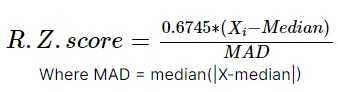

- 1.4826은 MAD를 정규분포의 표준편차와 같은 척도로 맞추기 위한 보정 상수

### 참고: Robust Z-score(Median/MAD 기반) 개념 정리

일반 z-score와 Robust z-score의 차이, 그리고 두 공식 표기가 동치임을 정리함.

**일반 Z-score의 한계**
- 일반 z-score는 평균(mean)과 표준편차(std)를 기준으로 계산하며, 평균과 표준편차 자체가 극단값(outlier)에 크게 영향을 받는 통계량임
- 본 프로젝트의 TransactionAmt, C컬럼군은 왜도가 매우 크고(예: TransactionAmt 왜도 14.4) 극단값이 다수 존재하는 분포로 확인되어, 일반 z-score 사용 시 평균과 표준편차 자체가 왜곡될 위험이 있음

**Robust Z-score 공식**
- Median(중앙값)과 MAD(Median Absolute Deviation, 중위절대편차)를 사용하여 극단값의 영향을 최소화함
- MAD = median(|x - median(x)|), 즉 각 값과 중앙값의 차이(절대값)를 구한 뒤 그 값들의 중앙값을 다시 취한 것

**공식 표기**
- R.Z.score = (x - median) / (1.4826 × MAD)
- R.Z.score = 0.6745 × (x - median) / MAD
- 두 표기는 수학적으로 동치임. 1.4826과 0.6745는 서로의 역수 관계이며, 표준정규분포에서 MAD의 이론적 값(약 0.6745)을 표준편차(σ=1)와 같은 척도로 보정하기 위한 상수임
- 분모에 1.4826을 곱하는 방식과 분자에 0.6745를 곱하는 방식은 계산 순서만 다를 뿐 결과는 동일함

**본 프로젝트에서의 활용**
- UID 기준 그룹별 거래금액에 대해 Robust z-score를 계산하여, 일반 z-score(평균/표준편차 기반) 대비 극단값에 더 안정적인 편차 지표로 활용함
- 일반 z-score와 Robust z-score의 Mann-Whitney U test 결과를 비교하여 어느 방식이 더 안정적인 신호를 제공하는지 검증함

In [ ]:
# def robust_zscore(series):
#     """median/MAD 기반 robust z-score 계산"""
#     median = series.median()
#     mad = (series - median).abs().median()
#     if mad == 0:
#         return pd.Series(np.nan, index=series.index)
#     return (series - median) / (1.4826 * mad)

# # UID 기준 그룹별로 robust z-score 계산
# df['amt_robust_zscore'] = df.groupby('UID', observed=True)['TransactionAmt'].transform(robust_zscore)

# # 그룹 내 거래가 1건뿐인 경우(MAD=0 또는 정의불가)는 NaN으로 남음 - 확인
# print(f"robust z-score 계산 불가 비율: {df['amt_robust_zscore'].isnull().mean():.1%}")
# print(f"\nrobust z-score 기초통계:\n{df['amt_robust_zscore'].describe()}")

robust z-score 계산 불가 비율: 6.2%

robust z-score 기초통계:
count    553847.000000
mean          0.612816
std         289.141954
min     -214942.546875
25%          -0.574286
50%           0.000000
75%           1.037157
max        3405.821777
Name: amt_robust_zscore, dtype: float64


In [19]:
print("MAD가 0은 아니지만 매우 작은 경우 확인:")
mad_by_uid = df.groupby('UID', observed=True)['TransactionAmt'].apply(
    lambda x: (x - x.median()).abs().median()
)
print(f"MAD가 0인 그룹: {(mad_by_uid == 0).sum()}개")
print(f"MAD가 0보다 크지만 0.01 미만인 그룹: {((mad_by_uid > 0) & (mad_by_uid < 0.01)).sum()}개")

print(f"\nrobust z-score 절댓값 상위 10개:")
print(df.nlargest(10, 'amt_robust_zscore', keep='all')[['UID', 'TransactionAmt', 'amt_robust_zscore']])
print(df.nsmallest(10, 'amt_robust_zscore', keep='all')[['UID', 'TransactionAmt', 'amt_robust_zscore']])

MAD가 0은 아니지만 매우 작은 경우 확인:
MAD가 0인 그룹: 21612개
MAD가 0보다 크지만 0.01 미만인 그룹: 2개

robust z-score 절댓값 상위 10개:
                      UID  TransactionAmt  amt_robust_zscore
422159   7970_490.0_325.0     1424.949951        3405.821777
104542  17480_181.0_220.0      200.000000        1902.093018
39343   10012_555.0_512.0       50.000000        1686.188354
277127  12839_321.0_251.0     2202.469971        1452.495605
515703  13899_555.0_299.0     1104.000000        1343.653076
87583      3376_488.0_nan       62.751999        1241.243408
23208    5567_583.0_123.0      100.000000        1106.181763
473910   9098_170.0_337.0     1364.949951        1016.630615
84404    9943_555.0_444.0      125.000000         890.341431
430966   9943_555.0_444.0      117.000000         782.421265
                      UID  TransactionAmt  amt_robust_zscore
94324   13815_514.0_337.0      100.000000     -214942.546875
153593  15592_494.0_343.0       49.000000       -4585.557617
96779   11518_479.0_436.0      100.000000   

### 해결: MAD에 최소 하한선(floor) 적용

- 분모가 너무 작아지는 걸 막기 위해, MAD의 최솟값을 일정 수준으로 강제. 
- 전체 데이터의 MAD를 기준으로 floor를 잡음.

In [20]:
def robust_zscore(series, mad_floor=None):
    """
    median/MAD 기반 robust z-score 계산.
    MAD가 0이거나 지나치게 작으면(분모 폭발 방지) NaN으로 처리한다.
    """
    median = series.median()
    mad = (series - median).abs().median()
    
    # MAD가 0이거나, 전체 데이터 기준 MAD의 일정 비율보다 작으면 계산 불가로 처리
    if mad_floor is not None and (mad == 0 or mad < mad_floor):
        return pd.Series(np.nan, index=series.index)
    if mad == 0:
        return pd.Series(np.nan, index=series.index)
    
    return (series - median) / (1.4826 * mad)

# 전체 데이터 기준 MAD를 계산해, 그 일정 비율(예: 5%)을 floor로 사용
global_median = df['TransactionAmt'].median()
global_mad = (df['TransactionAmt'] - global_median).abs().median()
mad_floor_value = global_mad * 0.05  # 전체 MAD의 5% 미만이면 신뢰 불가로 판단

print(f"전체 데이터 기준 MAD: {global_mad:.2f}")
print(f"적용할 MAD floor: {mad_floor_value:.4f}")

df['amt_robust_zscore'] = df.groupby('UID', observed=True)['TransactionAmt'].transform(
    lambda x: robust_zscore(x, mad_floor=mad_floor_value)
)

print(f"\nrobust z-score 계산 불가 비율: {df['amt_robust_zscore'].isnull().mean():.1%}")
print(f"\nrobust z-score 기초통계 (수정 후):\n{df['amt_robust_zscore'].describe()}")

전체 데이터 기준 MAD: 38.80
적용할 MAD floor: 1.9400

robust z-score 계산 불가 비율: 6.6%

robust z-score 기초통계 (수정 후):
count    551380.000000
mean          0.979422
std           4.914701
min        -186.172928
25%          -0.573317
50%           0.000000
75%           1.040298
max         523.118774
Name: amt_robust_zscore, dtype: float64


In [21]:
def test_mad_floor(df, floor_ratio):
    global_median = df['TransactionAmt'].median()
    global_mad = (df['TransactionAmt'] - global_median).abs().median()
    floor_value = global_mad * floor_ratio
    
    result = df.groupby('UID', observed=True)['TransactionAmt'].transform(
        lambda x: robust_zscore(x, mad_floor=floor_value)
    )
    return {
        'floor_ratio': floor_ratio,
        'floor_value': floor_value,
        'missing_pct': result.isnull().mean(),
        'std': result.std(),
        'min': result.min(),
        'max': result.max()
    }

floor_tests = [test_mad_floor(df, r) for r in [0.05, 0.1, 0.2, 0.3, 0.5]]
floor_test_df = pd.DataFrame(floor_tests)
print(floor_test_df.to_string(index=False))

 floor_ratio  floor_value  missing_pct      std         min        max
        0.05     1.940000     0.066312 4.914701 -186.172928 523.118774
        0.10     3.880000     0.071919 4.729365  -84.311348 523.118774
        0.20     7.759999     0.094480 4.221760  -66.739189 523.118774
        0.30    11.639999     0.128296 3.880866  -66.739189 523.118774
        0.50    19.399998     0.265018 3.917992  -66.739189 523.118774


**floor를 계속 올려도 max값(523.12)이 전혀 안 줄어듬 -> 다른 원인이 있다는 신호**

In [22]:
# floor_ratio=0.3 기준으로 재계산 (결측 13%, std 3.88로 균형 적절해 보임)
global_median = df['TransactionAmt'].median()
global_mad = (df['TransactionAmt'] - global_median).abs().median()
mad_floor_value = global_mad * 0.3

df['amt_robust_zscore'] = df.groupby('UID', observed=True)['TransactionAmt'].transform(
    lambda x: robust_zscore(x, mad_floor=mad_floor_value)
)

# max값을 만드는 거래 직접 확인
max_row = df.loc[df['amt_robust_zscore'].idxmax()]
print("최댓값을 만드는 거래:")
print(max_row[['UID', 'TransactionAmt', 'amt_robust_zscore', 'isFraud']])

# 그 UID의 전체 거래 내역 확인
target_uid = max_row['UID']
print(f"\nUID '{target_uid}'의 전체 거래 내역:")
print(df.loc[df['UID'] == target_uid, ['TransactionAmt', 'isFraud']].sort_values('TransactionAmt'))

최댓값을 만드는 거래:
UID                  16075_514.0_205.0
TransactionAmt            31937.390625
amt_robust_zscore           523.118774
isFraud                              0
Name: 274336, dtype: object

UID '16075_514.0_205.0'의 전체 거래 내역:
        TransactionAmt  isFraud
110263       40.000000        0
551764       43.950001        0
255367       45.950001        0
22022        49.950001        0
109896       50.000000        0
72516        53.950001        0
177669       53.950001        0
108720       53.950001        0
45310        53.950001        0
201526       58.950001        0
218331       58.950001        0
232664       58.950001        0
394261       58.950001        0
232712       63.950001        0
133207       73.949997        0
46140        75.000000        0
76188        75.000000        0
563191       83.949997        0
156286       88.949997        0
97256       100.000000        0
574809      100.000000        0
84432       100.000000        0
91146       100.000000        0

### Robust Z-score 검증 결과 요약

- floor_ratio를 0.05~0.5로 조정한 결과, min값은 floor 강화에 따라 점진적으로 안정화되었으나(-214942 → -66.7) max값(523.12)은 floor와 무관하게 고정되어 있어 별도 원인을 점검함
- max값을 생성하는 거래를 직접 확인한 결과, 해당 UID(40여 건의 거래가 대부분 40~450 사이에 분포)에서 전체 데이터 최댓값(31,937.39)과 일치하는 거래 2건이 발견됨
- 이는 계산 오류가 아니라, 해당 사용자의 평소 패턴 대비 실제로 극단적인 이상 거래를 robust z-score가 정확히 탐지한 결과로 확인됨
- 해당 거래는 isFraud=0(정상)으로 분류되어 있어, Day 2에서 확인한 "거래금액 최댓값은 오히려 정상 거래에서 발생한다"는 패턴과 일치함
- floor_ratio=0.3(MAD floor=11.64) 적용 시 결측 비율 12.8%, std 3.88로 안정적인 수준을 보여 최종 기준으로 채택함
- 동일 UID 내에 큰 금액 편차(40~450 vs 31,937)가 공존하는 사례는, UID(card1+card2+addr1)가 완벽한 개인 식별자가 아니라는 기존 한계(2.4절, Day 3 UID 검증)와도 일관되는 것으로 판단됨

### 6. 일반 z-score vs Robust z-score 비교 검정

두 방식의 Mann-Whitney U test 결과를 비교하여, robust 버전이 실제로 더 강한(또는 더 안정적인) 신호를 보이는지 확인합니다.

In [23]:
result_normal_z = mannwhitney_test(df, 'amt_zscore')
result_robust_z = mannwhitney_test(df, 'amt_robust_zscore')

comparison = pd.DataFrame([result_normal_z, result_robust_z])
print(comparison.to_string(index=False))

         variable  median_normal  median_fraud       u_stat       p_value  effect_size_r  significant
       amt_zscore      -0.288183     -0.162362 4890511186.0 4.513382e-125       0.099296         True
amt_robust_zscore       0.000000      0.253604 3976826667.0 9.668823e-155       0.115732         True


### 일반 Z-score vs Robust Z-score 최종 비교 결과 요약

- floor_ratio=0.3 적용 후 amt_robust_zscore의 effect size가 0.108 → 0.116으로 추가 개선됨. floor 적용으로 계산 오류성 극단값(분모 폭발)이 제거되면서 노이즈가 줄어들고 진짜 신호가 더 명확하게 드러난 것으로 판단됨
- 최종 비교: amt_zscore(effect size=0.099) < amt_robust_zscore(effect size=0.116) → robust 방식이 일반 방식보다 일관되게 더 강한 신호를 보임
- 정상 거래 중앙값(amt_robust_zscore=0.0)과 사기 거래 중앙값(0.254)의 차이가 일반 z-score보다 더 뚜렷하게 나타남
- 4.3절 최종 변수 세트에는 amt_robust_zscore를 amt_zscore보다 우선하여 채택하며, 두 변수 간 상관관계가 매우 높을 것으로 예상되어 다중공선성 방지를 위해 모델 입력 시 하나만 선택하거나 PCA 등으로 통합하는 것을 고려함

### 참고: Day 1 이상치 보존 결정과의 연결

Day 1에서 TransactionAmt 분석 시 "극단값을 제거하지 않고 로그변환 및 사용자별 금액 편차로 다룬다"고 결정했던 사항이, 오늘 Robust z-score 검증을 통해 실제로 의미 있는 결정이었음이 확인됨.

- Day 1에서 확인한 전체 데이터 최댓값(31,937.39)이, 오늘 Robust z-score 최댓값(523.12)을 생성한 거래와 동일한 금액으로 확인됨
- 만약 Day 1에서 이 거래를 이상치로 판단하여 제거했다면, "특정 사용자의 평소 패턴에서 극단적으로 벗어난 거래"라는 신호 자체가 분석에서 사라졌을 것임
- 제거하지 않고 보존한 결과, 동일한 거래가 전체 기준 절대값(31,937)이 아니라 사용자(UID) 기준 상대적 편차(평소 40~450 대비 500배 이상 벗어남)로 재해석되어 더 유의미한 형태의 정보로 전환됨
- 다만 해당 거래는 isFraud=0(정상)으로 확인되어, 금액 편차가 크다는 사실 자체가 사기의 충분조건은 아님을 보여줌. 따라서 amt_robust_zscore는 단독 판단 기준이 아니라 다른 변수와 결합하여 모델이 종합적으로 학습할 보조 신호로 활용함
- 이 사례는 "이상치 제거"와 "이상치를 변환하여 활용"이 서로 다른 결과를 낳을 수 있음을 보여주는 근거로, 보고서/블로그에 데이터 처리 의사결정의 타당성을 설명하는 사례로 활용 가능함

### 7. 시간대 기준 Z-score

UID 기준 편차 외에, 거래 시간대(hour) 기준으로도 금액 편차를 계산합니다. 같은 시간대(예: 새벽 시간)에 발생한 거래들 사이에서 이번 거래가 얼마나 벗어나는지를 측정하며, 이는 "행동 패턴 단위" 신호로 UID 기반 신호를 보완합니다.

이 작업을 위해 먼저 TransactionDT로부터 시간 파생변수(hour)를 생성합니다 (4.3절 작업 항목과 연계).

In [24]:
# 시간 파생변수 생성 (TransactionDT는 초 단위 경과시간)
df['Transaction_hour'] = (df['TransactionDT'] / 3600) % 24
df['Transaction_hour'] = df['Transaction_hour'].astype(int)

print("시간대별 거래 분포:")
print(df['Transaction_hour'].value_counts().sort_index())

# 시간대 기준 robust z-score
df['amt_hour_robust_zscore'] = df.groupby('Transaction_hour', observed=True)['TransactionAmt'].transform(
    lambda x: robust_zscore(x, mad_floor=mad_floor_value)
)

print(f"\n시간대 기준 robust z-score 계산 불가 비율: {df['amt_hour_robust_zscore'].isnull().mean():.1%}")
print(f"\n기초통계:\n{df['amt_hour_robust_zscore'].describe()}")

result_hour_z = mannwhitney_test(df, 'amt_hour_robust_zscore')
print(f"\n[Mann-Whitney 검정]\n{result_hour_z}")

시간대별 거래 분포:
Transaction_hour
0     37795
1     32797
2     26732
3     20802
4     14839
5      9701
6      6007
7      3704
8      2591
9      2479
10     3627
11     6827
12    12451
13    20315
14    28328
15    33859
16    38698
17    40723
18    41639
19    42115
20    41782
21    41641
22    41139
23    39949
Name: count, dtype: int64

시간대 기준 robust z-score 계산 불가 비율: 0.0%

기초통계:
count    590540.000000
mean          1.156606
std           4.259774
min          -1.425782
25%          -0.489849
50%           0.000000
75%           1.112317
max         613.400574
Name: amt_hour_robust_zscore, dtype: float64

[Mann-Whitney 검정]
{'variable': 'amt_hour_robust_zscore', 'median_normal': np.float32(0.0), 'median_fraud': np.float32(0.06498138), 'u_stat': np.float64(5857190951.0), 'p_value': np.float64(0.20525111099131943), 'effect_size_r': np.float64(0.005179162694889716), 'significant': np.False_}


### 참고: Transaction_hour 변수의 해석상 한계

TransactionDT 기반으로 생성한 Transaction_hour가 실제 현지 시각과 일치하는지 검증할 수 없다는 한계를 정리함.

**한계의 원인**
- TransactionDT는 Kaggle 공식 설명상 "임의의 기준 시점으로부터의 경과초(timedelta)"로만 명시되어 있으며, 그 기준 시점이 실제로 몇 시 몇 분에 해당하는지는 공개되어 있지 않음
- 따라서 `(TransactionDT / 3600) % 24`로 계산한 Transaction_hour 값이 실제 자정, 새벽, 오후 등 어느 시각에 대응하는지 확인할 방법이 없음

**안전하게 사용할 수 있는 범위**
- 24시간 주기로 거래량이 일관되게 변동하는 패턴이 존재한다는 사실 자체(특정 구간에서 최저/최고를 보임)
- Transaction_hour를 모델 입력 변수로 사용하는 것(모델은 값 자체로 학습하므로 실제 시각 의미와 무관하게 작동함)
- 통계검정에서 "이 위상(phase) 구간과 사기 여부가 연관 있는가"를 확인하는 것

**위험한 사용 방식 (지양)**
- "심야 시간대에 사기가 많다", "이른 아침 거래가 적은 것은 사람들이 자고 있어서다"와 같이 특정 시각대에 실생활 의미를 부여하는 해석
- 보고서·블로그에서 Transaction_hour 값을 실제 시각으로 단정하여 서술하는 것

**적용 원칙**
- 이후 Transaction_hour를 활용한 분석 결과는 "기준점으로부터 특정 위상 구간에 거래/사기가 몰린다"는 식으로 서술하며, 그 위상이 실제 새벽/낮/심야 중 어디에 해당하는지는 검증 불가능한 추정임을 명시함

### 시간대 기준 Z-score 검증 결과 요약

- 시간대별 거래 분포는 특정 구간(약 5~11시 위상)에서 최저(9시 위상에서 2,479건으로 최저점), 다른 구간(약 17~22시 위상)에서 최고(19시 위상에서 42,115건)를 보이는 뚜렷한 24시간 주기 패턴이 확인됨. 다만 이 위상이 실제 어느 시각대에 대응하는지는 검증할 수 없음(위 참고 항목 참조)
- amt_hour_robust_zscore는 통계적으로 유의하지 않음(p=0.205, effect size=0.005)으로 확인되어, 시간대 기준 편차는 사기탐지 신호로서 가치가 없는 것으로 판단됨
- 원인으로는 "시간대"라는 그룹 단위가 지나치게 크고(시간당 수천~수만 건) 그룹 내 개인별 소비 패턴 분산이 매우 커서, 개별 거래의 일탈이 그룹 분산에 묻히는 것으로 추정됨
- UID 기준 편차(amt_robust_zscore, effect size=0.116)와 비교했을 때, "개인에 가까운 단위"로 그룹화할 때만 편차 변수가 유의미한 신호를 갖는다는 점이 확인됨
- 결론: amt_hour_robust_zscore는 4.3절 최종 변수 세트에서 제외하며, 행동 패턴 단위 feature는 그룹 단위가 충분히 좁아야 효과가 있다는 시사점을 확인함

### 8. 그룹 결측 플래그 일괄 생성

Day 2에서 검증한 V컬럼 15개 그룹(12개 그룹이 통계적으로 유의)을 기준으로, 각 그룹의 대표 결측 플래그를 정식 변수로 생성합니다. 통계적으로 무의미했던 V_group1, 2, 3은 결측 플래그 생성에서 제외합니다.

In [27]:
# 잘못 생성된 V_group*_missing 컬럼 제거
wrong_flags = [c for c in df.columns if re.match(r'^V_group\d+_missing$', c)]
df = df.drop(columns=wrong_flags)
print(f"제거된 컬럼: {wrong_flags}")

# V컬럼을 'V+숫자' 패턴으로만 명확히 한정 (재실행해도 안전하도록)
v_cols = [c for c in df.columns if re.fullmatch(r'V\d+', c)]
print(f"\n정확한 V컬럼 개수: {len(v_cols)}")  # 339가 나와야 정상

제거된 컬럼: ['V_group1_missing', 'V_group4_missing', 'V_group5_missing', 'V_group6_missing', 'V_group7_missing', 'V_group8_missing', 'V_group9_missing', 'V_group10_missing', 'V_group12_missing', 'V_group15_missing', 'V_group16_missing']

정확한 V컬럼 개수: 339


In [30]:
import re

# V컬럼을 'V+숫자' 패턴으로만 명확히 한정 (재실행 시에도 항상 339개로 고정됨)
v_cols = [c for c in df.columns if re.fullmatch(r'V\d+', c)]
v_missing_pct = (df[v_cols].isnull().sum() / len(df) * 100).round(4)

v_group_df = v_missing_pct.reset_index()
v_group_df.columns = ['column', 'missing_pct']
v_groups = v_group_df.groupby('missing_pct')['column'].apply(list).reset_index()
v_groups['n_cols'] = v_groups['column'].apply(len)
# n_cols 내림차순, 동률 시 missing_pct 오름차순으로 순서 고정 (재현성 확보)
v_groups = v_groups.sort_values(['n_cols', 'missing_pct'], ascending=[False, True]).reset_index(drop=True)

print(f"V컬럼 {len(v_cols)}개가 {len(v_groups)}개 그룹으로 분류됨")

v_flag_summary = []
for i, row in v_groups.iterrows():
    representative_col = row['column'][0]
    flag_name = f'V_group{i+1}_missing'
    df[flag_name] = df[representative_col].isnull().astype(np.int8)
    
    result = chi_square_test(df, flag_name)
    result['n_cols_in_group'] = row['n_cols']
    result['flag_name'] = flag_name
    v_flag_summary.append(result)

v_flag_summary_df = pd.DataFrame(v_flag_summary)

SIGNIFICANT_THRESHOLD = 0.02
adopted_flags = v_flag_summary_df[
    (v_flag_summary_df['significant']) & (v_flag_summary_df['cramers_v'] >= SIGNIFICANT_THRESHOLD)
]
dropped_flags = v_flag_summary_df[
    ~((v_flag_summary_df['significant']) & (v_flag_summary_df['cramers_v'] >= SIGNIFICANT_THRESHOLD))
]

print(f"\n채택할 V그룹 결측 플래그: {len(adopted_flags)}개")
print(adopted_flags[['flag_name', 'n_cols_in_group', 'cramers_v']].to_string(index=False))

print(f"\n제외할 V그룹 결측 플래그: {len(dropped_flags)}개")
print(dropped_flags[['flag_name', 'n_cols_in_group', 'cramers_v']].to_string(index=False))

df = df.drop(columns=dropped_flags['flag_name'].tolist())

V컬럼 339개가 15개 그룹으로 분류됨

채택할 V그룹 결측 플래그: 11개
        flag_name  n_cols_in_group  cramers_v
 V_group1_missing               46   0.125019
 V_group4_missing               31   0.133444
 V_group5_missing               23   0.033690
 V_group6_missing               22   0.049533
 V_group7_missing               20   0.029745
 V_group8_missing               19   0.133912
V_group10_missing               18   0.021389
V_group11_missing               18   0.020852
V_group12_missing               16   0.130283
V_group14_missing               11   0.088307
V_group15_missing               11   0.020873

제외할 V그룹 결측 플래그: 4개
        flag_name  n_cols_in_group  cramers_v
 V_group2_missing               43   0.002204
 V_group3_missing               32   0.002208
 V_group9_missing               18   0.003737
V_group13_missing               11   0.000218


### 참고: V그룹 번호 고정 (재현성 확보)

V_group 번호가 실행마다 달라질 수 있는 문제와 해결 방법을 정리함.

**문제 원인**
- 그룹 정렬 기준이 n_cols(그룹 크기) 내림차순이었으나, 그룹 크기가 동일한 경우가 존재함(18개 컬럼 그룹 3개, 11개 컬럼 그룹 3개)
- 동률 항목의 순서는 정렬 전 원래 순서에 의존하며, 이는 실행 환경이나 그룹화 과정의 미세한 차이에 따라 달라질 수 있음
- 실제로 Day 2와 Day 3 실행에서 18개 컬럼 그룹들의 번호가 서로 바뀌어 나타남을 확인함

**해결**
- 정렬 기준에 missing_pct(결측률 값)를 보조 기준으로 추가하여 동률을 깨고 순서를 고정함: `sort_values(['n_cols', 'missing_pct'], ascending=[False, True])`
- 동률 그룹 수(3개씩)와 무관하게, 보조 정렬 기준이 모든 동률을 완전히 구분하므로 몇 번을 재실행해도 동일한 그룹이 항상 동일한 번호를 받음

**유의점**
- 그룹 번호 자체는 임의의 라벨이며, Cramér's V 등 통계값은 그룹 구성과 무관하게 항상 동일함(Day 2-Day 3 비교에서 확인)
- 다만 보고서·블로그에 그룹 번호를 인용하여 서술할 경우, 노트북 재실행 시에도 동일한 그룹을 가리키도록 정렬 기준을 고정하는 것이 분석 재현성 확보에 필요함

### Day 3 중간 저장

세션 종료에 대비하여 현재까지의 작업 결과를 저장합니다. 다음 세션에서는 V컬럼 차원축소(그룹별 대표변수 또는 PCA)부터 이어갑니다.

In [31]:
import os
df.to_parquet("../data/processed/day3_merged.parquet", index=False)
print("저장 완료, 파일 크기(MB):", os.path.getsize("../data/processed/day3_merged.parquet") / 1024**2)

저장 완료, 파일 크기(MB): 99.13948440551758


## Day 3 (이어서). V컬럼 차원축소, 시간 파생변수, 최종 변수 세트 정리

In [7]:
import pandas as pd
import numpy as np
import re
import sys
sys.path.append("..")

from src.eval_metrics import chi_square_test, mannwhitney_test, reduce_mem_usage

pd.set_option('display.max_columns', 100)

df = pd.read_parquet("../data/processed/day3_merged.parquet")
print("shape:", df.shape)

v_cols = [c for c in df.columns if re.fullmatch(r'V\d+', c)]
print(f"V컬럼 개수: {len(v_cols)}")

adopted_v_flags = [c for c in df.columns if re.fullmatch(r'V_group\d+_missing', c)]
print(f"채택된 V그룹 결측 플래그: {len(adopted_v_flags)}개")

v_missing_pct = (df[v_cols].isnull().sum() / len(df) * 100).round(4)

v_group_df = v_missing_pct.reset_index()
v_group_df.columns = ['column', 'missing_pct']
v_groups = v_group_df.groupby('missing_pct')['column'].apply(list).reset_index()
v_groups['n_cols'] = v_groups['column'].apply(len)
v_groups = v_groups.sort_values(['n_cols', 'missing_pct'], ascending=[False, True]).reset_index(drop=True)

print(f"V컬럼 {len(v_cols)}개가 {len(v_groups)}개 그룹으로 재생성됨")
print(v_groups[['n_cols', 'missing_pct']].to_string())

shape: (590540, 462)
V컬럼 개수: 339
채택된 V그룹 결측 플래그: 11개
V컬럼 339개가 15개 그룹으로 재생성됨
    n_cols  missing_pct
0       46      77.9134
1       43       0.0532
2       32       0.0020
3       31      76.3554
4       23      12.8819
5       22      13.0552
6       20      15.0987
7       19      76.3235
8       18      28.6126
9       18      86.0550
10      18      86.1237
11      16      76.0531
12      11       0.2149
13      11      47.2935
14      11      86.1227


### 9. V그룹 내 상관관계 사전 검증

결측 패턴이 동일한 그룹이라도 실제 값들의 상관관계가 낮으면 PCA 적용이 부적절할 수 있습니다. 15개 그룹 각각에 대해 그룹 내 평균 절대 상관계수를 확인하여, PCA 적용의 타당성을 사전 검증합니다.

In [8]:
def group_avg_correlation(df, cols):
    """그룹 내 컬럼들의 평균 절대 상관계수 계산 (결측 제외, pairwise)"""
    if len(cols) < 2:
        return np.nan
    corr_matrix = df[cols].corr().abs()
    # 대각선(자기 자신과의 상관=1)을 제외한 평균
    n = len(cols)
    avg_corr = (corr_matrix.values.sum() - n) / (n * n - n)
    return avg_corr

correlation_summary = []
for i, row in v_groups.iterrows():
    cols = row['column']
    avg_corr = group_avg_correlation(df, cols)
    correlation_summary.append({
        'group': f"V_group{i+1}",
        'n_cols': row['n_cols'],
        'missing_pct': row['missing_pct'],
        'avg_abs_correlation': avg_corr
    })

corr_summary_df = pd.DataFrame(correlation_summary)
print(corr_summary_df.to_string(index=False))

    group  n_cols  missing_pct  avg_abs_correlation
 V_group1      46      77.9134             0.339861
 V_group2      43       0.0532             0.254956
 V_group3      32       0.0020             0.311305
 V_group4      31      76.3554             0.405431
 V_group5      23      12.8819             0.276653
 V_group6      22      13.0552             0.324966
 V_group7      20      15.0987             0.291719
 V_group8      19      76.3235             0.299155
 V_group9      18      28.6126             0.323216
V_group10      18      86.0550             0.566780
V_group11      18      86.1237             0.426343
V_group12      16      76.0531             0.398123
V_group13      11       0.2149             0.306236
V_group14      11      47.2935             0.284776
V_group15      11      86.1227             0.581245


### V그룹 상관관계 검증 결과 및 차원축소 전략 확정

- 15개 그룹의 평균 절대 상관계수는 0.255~0.581 범위로 나타나, 모든 그룹에서 최소한의 상관관계가 확인됨 (결측 패턴이 동일해도 값이 무관한 경우는 없음을 확인)
- 결측률이 높은 그룹(V_group10: 86.06%, V_group15: 86.12%)이 상관관계도 가장 높게(0.57~0.58) 나타나, 드물게 기록되는 정밀 측정값일수록 서로 강하게 연동되는 경향으로 추정됨
- 그룹 크기(n_cols)와 상관관계(avg_abs_correlation)를 종합하여 다음과 같이 차원축소 전략을 확정함

| 그룹 | n_cols | avg_corr | 처리 방식 |
|---|---|---|---|
| V_group1, 4 | 46, 31 | 0.34, 0.41 | PCA (95% 설명분산) |
| V_group3 | 32 | 0.31 | PCA (90% 설명분산) |
| V_group6, 9, 11, 12 | 22, 18, 18, 16 | 0.32~0.43 | PCA (90% 설명분산) |
| V_group2, 5, 7, 8 | 43, 23, 20, 19 | 0.26~0.30 | PCA (85% 설명분산, 상관 낮아 압축률 낮게) |
| V_group10, 15 | 18, 11 | 0.57, 0.58 | PCA (95% 설명분산, 상관 매우 높아 적은 주성분으로도 충분) |
| V_group13, 14 | 11, 11 | 0.31, 0.28 | 원본 유지 (컬럼 수 11개로 적어 PCA 압축 효율 낮음) |

- 그룹 크기 11개인 V_group13, 14는 컬럼 수가 적어 PCA의 이점이 제한적이라고 판단하여 원본을 유지하며, 나머지 13개 그룹은 PCA를 적용함

### 10. V그룹별 PCA 적용

확정한 전략에 따라 13개 그룹(V_group13, 14 제외)에 PCA를 적용합니다. 그룹별 목표 누적 설명분산 기준에 맞춰 주성분 개수를 자동으로 결정합니다.

**처리 순서**
1. 그룹 내 결측치를 그룹별 중앙값(median)으로 임시 대체 (PCA는 결측치를 허용하지 않음)
2. 표준화(StandardScaler) — PCA는 스케일에 민감하므로 필수
3. 목표 누적 설명분산을 만족하는 최소 주성분 개수로 변환
4. 원본 V컬럼 제거, 주성분 변수로 교체

In [9]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 그룹별 PCA 목표 설명분산 설정 (avg_corr 기준)
pca_config = {
    'V_group1': 0.95, 'V_group4': 0.95,
    'V_group3': 0.90,
    'V_group6': 0.90, 'V_group9': 0.90, 'V_group11': 0.90, 'V_group12': 0.90,
    'V_group2': 0.85, 'V_group5': 0.85, 'V_group7': 0.85, 'V_group8': 0.85,
    'V_group10': 0.95, 'V_group15': 0.95,
}
exclude_from_pca = ['V_group13', 'V_group14']  # 원본 유지

pca_results = []
new_pca_columns = []
cols_to_drop = []

for i, row in v_groups.iterrows():
    group_name = f"V_group{i+1}"
    cols = row['column']
    
    if group_name in exclude_from_pca:
        continue
    
    target_variance = pca_config[group_name]
    
    # 1) 결측치 그룹별 중앙값으로 임시 대체
    group_data = df[cols].copy()
    group_data = group_data.fillna(group_data.median())
    
    # 2) 표준화
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(group_data)
    
    # 3) PCA 적용 (전체 주성분으로 먼저 학습 후, 목표 분산 만족하는 개수 선택)
    pca_full = PCA()
    pca_full.fit(scaled_data)
    cumsum_variance = np.cumsum(pca_full.explained_variance_ratio_)
    n_components = np.argmax(cumsum_variance >= target_variance) + 1
    n_components = max(1, min(n_components, len(cols)))
    
    # 4) 최종 PCA 변환
    pca = PCA(n_components=n_components)
    pca_transformed = pca.fit_transform(scaled_data)
    
    for j in range(n_components):
        col_name = f"{group_name}_PC{j+1}"
        df[col_name] = pca_transformed[:, j]
        new_pca_columns.append(col_name)
    
    cols_to_drop.extend(cols)
    
    pca_results.append({
        'group': group_name,
        'n_original_cols': len(cols),
        'target_variance': target_variance,
        'n_components': n_components,
        'actual_variance_explained': cumsum_variance[n_components-1],
        'compression_ratio': f"{len(cols)} -> {n_components}"
    })

pca_results_df = pd.DataFrame(pca_results)
print(pca_results_df.to_string(index=False))

print(f"\n전체 압축 결과: V컬럼 {len(cols_to_drop)}개 -> 주성분 {len(new_pca_columns)}개")
print(f"제외(원본 유지)된 그룹: {exclude_from_pca} (각 11개 컬럼, 총 22개)")

    group  n_original_cols  target_variance  n_components  actual_variance_explained compression_ratio
 V_group1               46             0.95            12                   0.954564          46 -> 12
 V_group2               43             0.85             9                   0.852398           43 -> 9
 V_group3               32             0.90             8                   0.914307           32 -> 8
 V_group4               31             0.95             7                   0.955749           31 -> 7
 V_group5               23             0.85             7                   0.886451           23 -> 7
 V_group6               22             0.90             8                   0.915333           22 -> 8
 V_group7               20             0.85             7                   0.880541           20 -> 7
 V_group8               19             0.85             6                   0.880269           19 -> 6
 V_group9               18             0.90             7                

### 참고: 원본 유지 그룹(V_group13, 14)의 상대적 영향력에 대한 검토

PCA로 차원이 축소된 다른 그룹(5~12개 주성분)과 비교했을 때, 원본을 유지한 V_group13·14(각 11개 컬럼)의 컬럼 수가 상대적으로 많아 모델에 미치는 영향력이 불균형해질 가능성을 검토함.

**모델별 영향 검토**
- LightGBM, XGBoost(트리 기반): 각 변수를 독립적으로 평가하여 분기 기준의 정보 이득에 따라 선택하므로, 그룹 내 컬럼 개수 자체가 영향력으로 직결되지 않음. 11개 컬럼 중 실제로 유용한 일부만 분기에 활용됨
- Logistic Regression: 거리/계수 기반 모델 특성상 변수 개수가 상대적 영향력에 영향을 줄 수 있으나, L1/L2 정규화 적용 및 전체 변수 세트에 대한 일관된 표준화로 완화 가능

**결론 및 후속 조치**
- 본 프로젝트의 핵심 모델(LightGBM, XGBoost)에서는 그룹별 컬럼 수 차이가 실질적 문제가 되지 않는 것으로 판단됨
- 다만 Logistic Regression 적용 시 공정성을 위해, Day 4 모델링 단계에서 PCA 주성분·원본 유지 컬럼·기타 모든 변수를 포함한 전체 변수 세트에 대해 일관된 표준화(StandardScaler)를 재적용할 것을 체크리스트에 반영함 (PCA 단계의 그룹별 표준화는 PCA 계산 목적의 임시 처리이며, 최종 모델 입력 표준화와는 별개임)

In [10]:
print(f"제거 전 shape: {df.shape}")
df = df.drop(columns=cols_to_drop)
print(f"제거 후 shape: {df.shape}")

# 검증: PCA 주성분과 원본 유지 컬럼이 잘 남아있는지 확인
remaining_v_cols = [c for c in df.columns if re.fullmatch(r'V\d+', c)]
pca_cols = [c for c in df.columns if 'V_group' in c and '_PC' in c]
print(f"\n남은 원본 V컬럼(V_group13,14): {len(remaining_v_cols)}개")
print(f"PCA 주성분 컬럼: {len(pca_cols)}개")

제거 전 shape: (590540, 551)
제거 후 shape: (590540, 234)

남은 원본 V컬럼(V_group13,14): 22개
PCA 주성분 컬럼: 89개


### V그룹 PCA 적용 결과 요약

- 13개 그룹(V_group1~12, 15)에 PCA를 적용하여 317개 컬럼을 89개 주성분으로 압축함 (약 72% 차원 감소)
- 그룹별 압축률은 상관관계 강도와 비례하는 경향을 보임: 상관관계가 높았던 V_group10·11·15(avg_corr 0.43~0.58)는 18→5, 11→3 등 4~6배 압축되었고, 상관관계가 상대적으로 낮았던 V_group2·5(avg_corr 0.26~0.28)는 43→9, 23→7로 압축률이 다소 낮게 나타남
- 모든 그룹에서 목표 설명분산(85~95%) 이상을 실제로 달성함을 확인함
- V_group13·14(각 11개 컬럼, avg_corr 0.28~0.31)는 컬럼 수가 적어 PCA 압축 효율이 낮다고 판단하여 원본 22개 컬럼을 그대로 유지함
- **종합 결과**: V컬럼 339개 → PCA 주성분 89개 + 원본 유지 22개 = 최종 111개로 압축됨 (약 67% 차원 감소). 여기에 결측 플래그 11개를 더하면 V컬럼군 전체가 122개 변수로 정리됨
- 결측치는 PCA 계산을 위해 그룹별 중앙값으로 임시 대체하였으나, 실제 결측 정보는 별도의 결측 플래그 변수(V_group*_missing)가 보존하므로 정보 손실 없이 역할을 분리함

### 참고: 다중공선성 검증 계획 누락 확인 및 보완

지금까지 V그룹 내부 상관관계만 확인했고, 최종 변수 세트 전체에 대한 다중공선성 검증이 누락되었음을 확인하여 계획에 반영함.

**현재까지 확인한 것**
- V그룹 내부 컬럼들 간 평균 절대 상관계수 (PCA 적용 타당성 검증 목적)

**아직 확인하지 않은 것**
- PCA 주성분, 원본 유지 컬럼, C컬럼군, amt_robust_zscore, D1 등 최종 변수 세트 전체를 합쳤을 때의 변수 간 다중공선성

**필요성**
- 다중공선성이 심한 변수들을 모델에 함께 입력하면, Logistic Regression에서는 계수 추정이 불안정해지고, 트리 기반 모델에서도 변수 중요도 해석이 왜곡될 수 있음

**계획**
- Day 3 최종 변수 세트 정리 단계에서, 상관계수 행렬과 VIF(Variance Inflation Factor)를 함께 확인하여 다중공선성이 심한 변수 쌍/그룹을 식별함
- 발견 시 변수 제거, 통합, 또는 정규화 강화 등으로 대응하며, 이 작업을 모델링(Day 4) 이전에 완료함

### 11. 시간 파생변수 생성

TransactionDT(경과초) 기반으로 day, weekday, month를 생성합니다. hour는 이미 Day 3 초반에 생성했으나, Transaction_hour의 해석 한계(실제 시각 불명확)와 동일한 한계가 day/weekday/month에도 적용됨을 유의합니다.

전체 데이터가 182일(약 6.1개월) 분량임을 Day 2에서 확인하였으므로, month는 약 6개 구간으로 나뉠 것으로 예상됩니다. month는 4.11절 Drift 분석의 시간 구간 분할 기준으로 사용됩니다.

In [11]:
SECONDS_PER_DAY = 86400

df['Transaction_day'] = (df['TransactionDT'] / SECONDS_PER_DAY).astype(int)
df['Transaction_weekday'] = df['Transaction_day'] % 7  # 0~6, 실제 요일과의 대응은 불명확 (한계 동일 적용)
df['Transaction_month'] = (df['Transaction_day'] / 30).astype(int)  # 약 30일 단위로 월 구간 근사

print("Transaction_weekday별 거래 건수:")
print(df['Transaction_weekday'].value_counts().sort_index())

print("\nTransaction_month별 거래 건수:")
print(df['Transaction_month'].value_counts().sort_index())

print(f"\nmonth 범위: {df['Transaction_month'].min()} ~ {df['Transaction_month'].max()}")

Transaction_weekday별 거래 건수:
Transaction_weekday
0    86377
1    98502
2    79834
3    70223
4    85433
5    84815
6    85356
Name: count, dtype: int64

Transaction_month별 거래 건수:
Transaction_month
0    130968
1     89838
2     91768
3     98027
4     85303
5     86525
6      8111
Name: count, dtype: int64

month 범위: 0 ~ 6


**한계 적용**: Transaction_hour와 동일하게, Transaction_day/weekday/month는 TransactionDT의 임의 기준점에서 파생된 값으로, 실제 요일(월~일)이나 특정 달(1~12월)과의 대응 관계는 검증 불가능함. 분석 시 "특정 위상(phase) 구간"으로 서술하며, 절대적 시점 의미를 부여하지 않음.

### 참고: Transaction_month 마지막 구간의 불완전성

month=6 구간이 8,111건으로 다른 구간(85,303~130,968건)보다 현저히 적게 나타난 원인을 확인함.

- 전체 데이터는 182일(6.1개월) 분량이며, 30일 단위로 month를 구분할 경우 마지막 구간(180~182일)은 2일치 데이터만 포함되어 불완전한 구간이 됨
- 이 불균형은 데이터 자체의 결측이나 오류가 아니라, 182일을 30일 단위로 나눌 때 발생하는 자연스러운 나머지(182 = 30×6 + 2)임
- 4.11절 Drift 분석에서 학습/검증 구간을 month 기준으로 분할할 계획이므로, month=6을 단독 검증 구간으로 사용하면 표본 부족으로 통계적 검정(PSI, KS test)이 불안정해질 위험이 있음
- 대응 방안: month=6을 month=5와 병합하여 마지막 구간을 32일치로 구성하거나, Drift 분석 시 month=0~4를 학습 구간, month=5+6(통합, 32일)을 검증 구간으로 설정하는 방식을 4.11절에서 적용함

### 12. 그룹별 대표변수 버전 생성 (PCA 버전과 비교용)

PCA로 압축한 버전과 별도로, 각 그룹에서 ~~분산이 가장 큰~~ 컬럼 1개를 대표변수로 선정하는 단순한 버전을 만듭니다. Day 4에서 동일 모델(LightGBM)로 두 버전의 PR-AUC를 비교하여 차원축소 방식의 타당성을 검증합니다.

이 버전은 모델링에 바로 쓰지 않고, 별도 비교 실험용 데이터셋으로 따로 저장합니다.

In [12]:
# 원본 V컬럼 데이터가 필요하므로, day2_merged.parquet에서 다시 불러와 대표변수만 추출
df_for_repr = pd.read_parquet("../data/processed/day2_merged.parquet")

representative_cols = []
representative_summary = []

for i, row in v_groups.iterrows():
    group_name = f"V_group{i+1}"
    cols = row['column']
    
    # 그룹 내에서 분산이 가장 큰 컬럼을 대표로 선정 (결측 제외하고 계산)
    variances = df_for_repr[cols].var()
    best_col = variances.idxmax()
    
    representative_cols.append(best_col)
    representative_summary.append({
        'group': group_name,
        'n_cols_in_group': len(cols),
        'representative_col': best_col,
        'variance': variances[best_col]
    })

repr_summary_df = pd.DataFrame(representative_summary)
print(repr_summary_df.to_string(index=False))

# 대표변수 버전 데이터셋 구성 (비교 실험용으로 별도 저장)
non_v_cols = [c for c in df.columns if not re.fullmatch(r'V\d+', c) and 'V_group' not in c]
df_representative_version = pd.concat([
    df[non_v_cols],
    df_for_repr[representative_cols].rename(columns={c: f"V_repr_{c}" for c in representative_cols})
], axis=1)

print(f"\n대표변수 버전 shape: {df_representative_version.shape}")
print(f"PCA 버전(현재 df) shape: {df.shape}")

    group  n_cols_in_group representative_col     variance
 V_group1               46               V264 5.220436e+06
 V_group2               43               V127 1.796630e+07
 V_group3               32               V307 1.928960e+07
 V_group4               31               V203 8.291210e+07
 V_group5               23                V30 3.072604e-01
 V_group6               22                V56 4.370909e-01
 V_group7               20                V78 6.107017e-01
 V_group8               19               V209 6.290105e+04
 V_group9               18                V38 7.377437e-01
V_group10               18               V332 1.247527e+08
V_group11               18               V162 4.787973e+03
V_group12               16               V271 5.497885e+03
V_group13               11               V314 3.014357e+04
V_group14               11                V11 3.051798e-01
V_group15               11               V160 2.018561e+10

대표변수 버전 shape: (590540, 129)
PCA 버전(현재 df) shape: (5905

In [13]:
representative_cols_v2 = []
representative_summary_v2 = []

for i, row in v_groups.iterrows():
    group_name = f"V_group{i+1}"
    cols = row['column']
    
    # 분산 대신, 그룹 내 각 컬럼의 Mann-Whitney effect size로 대표변수 선정
    effect_sizes = {}
    for col in cols:
        if df_for_repr[col].notna().sum() > 0:  # 결측 아닌 값이 있는 경우만
            result = mannwhitney_test(df_for_repr, col)
            effect_sizes[col] = result['effect_size_r']
    
    best_col = max(effect_sizes, key=effect_sizes.get)
    
    representative_cols_v2.append(best_col)
    representative_summary_v2.append({
        'group': group_name,
        'n_cols_in_group': len(cols),
        'representative_col': best_col,
        'effect_size_r': effect_sizes[best_col]
    })

repr_summary_v2_df = pd.DataFrame(representative_summary_v2)
print(repr_summary_v2_df.to_string(index=False))

    group  n_cols_in_group representative_col  effect_size_r
 V_group1               46               V258       0.490577
 V_group2               43               V102       0.179459
 V_group3               32               V303       0.325107
 V_group4               31               V199       0.387147
 V_group5               23                V34       0.352771
 V_group6               22                V74       0.341606
 V_group7               20                V94       0.364380
 V_group8               19               V201       0.393177
 V_group9               18                V52       0.405070
V_group10               18               V332       0.150272
V_group11               18               V140       0.353804
V_group12               16               V222       0.216818
V_group13               11               V283       0.292720
V_group14               11                V10       0.277977
V_group15               11               V150       0.201123


In [14]:
representative_cols = repr_summary_v2_df['representative_col'].tolist()

non_v_cols = [c for c in df.columns if not re.fullmatch(r'V\d+', c) and 'V_group' not in c]
df_representative_version = pd.concat([
    df[non_v_cols],
    df_for_repr[representative_cols].rename(columns={c: f"V_repr_{c}" for c in representative_cols})
], axis=1)

print(f"대표변수 버전(effect size 기준) shape: {df_representative_version.shape}")
print(f"PCA 버전(현재 df) shape: {df.shape}")

# 비교 실험용으로 별도 저장
df_representative_version.to_parquet("../data/processed/day3_representative_version.parquet", index=False)
print("\n대표변수 버전 저장 완료")

대표변수 버전(effect size 기준) shape: (590540, 129)
PCA 버전(현재 df) shape: (590540, 236)

대표변수 버전 저장 완료


### 대표변수 선정 기준 재검토 결과 요약

- 분산 기준 선정과 Mann-Whitney effect size 기준 선정을 비교한 결과, 15개 그룹 중 14개 그룹에서 서로 다른 컬럼이 선정됨 (V_group10만 동일)
- 분산 기준은 "값이 다양하게 퍼져있는가"를 측정하지만 이것이 "사기를 잘 구분하는가"와 동일하지 않으며, 분산이 극단치 하나에 의해 왜곡될 수 있다는 점(Day 1~2에서 TransactionAmt, C컬럼에서 확인한 패턴과 동일)에서 한계가 있는 것으로 판단됨
- Effect size 기준으로 재선정한 결과, V_group1의 대표변수 V258이 effect size 0.491로 지금까지 검정한 모든 변수(C4: 0.375 포함) 중 가장 강한 신호를 보임
- V_group9(0.405), V_group8(0.393), V_group4(0.387) 등 다수가 C컬럼 상위권과 동등한 수준의 신호를 보여, 분산 기준으로는 발견하지 못했던 강한 신호 변수들이 확인됨
- 최종 대표변수는 Mann-Whitney effect size 기준으로 확정하며, 분산 기준 선정 결과는 채택하지 않음
- 참고: PCA 또한 분산 보존을 목표로 하는 기법이라 유사한 한계(타겟 판별력과 무관하게 분산 구조만 보존)를 가질 수 있음을 인지하며, 이는 PCA 버전과 대표변수 버전의 Day 4 성능 비교에서 추가로 검증함

### 13. 최종 변수 세트 다중공선성 검증

PCA 버전(현재 df, 236개 컬럼)을 기준으로, 최종 변수 세트 전체에 대한 다중공선성을 검증합니다.

**검증 방법**
1. 상관계수 행렬: 변수 쌍별 상관관계 확인 (절댓값 0.8 이상을 높은 상관으로 판단)
2. VIF(Variance Inflation Factor): 다중공선성의 정식 지표 (VIF > 10이면 심각한 다중공선성으로 판단)

**대상**: isFraud, TransactionID 등 식별자/타겟 변수를 제외한 수치형 변수 전체

In [15]:
exclude_cols = ['isFraud', 'TransactionID', 'UID', 'UID_temp', 'UID_v2', 'TransactionDT']
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in exclude_cols]

print(f"다중공선성 검증 대상 변수 개수: {len(numeric_cols)}")

corr_matrix = df[numeric_cols].corr().abs()

# 상관계수 0.8 이상인 변수 쌍 추출 (자기 자신과의 상관 제외)
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        val = corr_matrix.iloc[i, j]
        if val >= 0.8:
            high_corr_pairs.append({
                'var1': corr_matrix.columns[i],
                'var2': corr_matrix.columns[j],
                'correlation': val
            })

high_corr_df = pd.DataFrame(high_corr_pairs).sort_values('correlation', ascending=False)
print(f"\n상관계수 0.8 이상인 변수 쌍: {len(high_corr_df)}개")
print(high_corr_df.head(30).to_string(index=False))

다중공선성 검증 대상 변수 개수: 181

상관계수 0.8 이상인 변수 쌍: 121개
             var1                   var2  correlation
               D9       Transaction_hour     1.000000
               D4                    D12     0.999999
V_group11_missing      V_group15_missing     0.999957
               C7                    C12     0.999489
 V_group4_missing       V_group8_missing     0.998313
V_group10_missing      V_group15_missing     0.997176
V_group10_missing      V_group11_missing     0.997134
               C8                    C10     0.996970
               C1                    C11     0.996515
   TransactionAmt amt_hour_robust_zscore     0.995497
               C1                     C2     0.995089
               C2                    C11     0.993898
               C6                    C11     0.991105
  Transaction_day      Transaction_month     0.986751
               D5                     D7     0.986496
 V_group4_missing      V_group12_missing     0.986116
 V_group8_missing      V_group12_m

### 참고: 다중공선성 검증 시점에 대한 회고

다중공선성 검증을 변수 생성 완료 후(현 단계)에 진행한 것이 적절했는지 점검하고, 향후 프로젝트를 위한 원칙을 정리함.

**다중공선성 검증의 두 단계**
1. 1차 검증(그룹 내부, 변수 생성 전): V그룹 내 평균 상관계수 확인(0.255~0.581) 후 PCA 적용 타당성을 판단한 것이 이에 해당하며, 적절한 시점에 수행됨
2. 2차 검증(전체 변수 간, 최종 세트 완성 후): 그룹 간(C컬럼군, D컬럼군, 원본-파생변수 간) 다중공선성은 모든 후보 변수가 모인 뒤에야 확인 가능하므로, 현 단계에서의 검증이 구조적으로 필요함

**더 일찍 확인했다면 효율적이었을 지점**
- Day 2에서 C4·C8·C10·C12를 강한 신호로 채택할 때, 동시에 이 변수들 간 상관관계도 확인했다면 중복 발견을 더 일찍 할 수 있었음 (실제로 C8-C10 상관계수 0.997로 거의 중복)
- Day 3에서 Transaction_hour를 생성하기 전, D1~D15 중 유사한 정보(D9)가 이미 존재하는지 먼저 확인했다면 완전 중복(상관계수 1.000) 생성을 피할 수 있었음

**향후 프로젝트 적용 원칙**
1. 개별 변수의 신호 강도 검정과 동시에, 강한 신호로 채택된 변수들 간 상관관계를 함께 확인하는 습관화
2. 새로운 파생변수 생성 전, 유사한 정보를 가진 원본 변수가 이미 존재하는지 사전 점검
3. 위 1, 2를 거쳤더라도, 변수들이 모두 모인 최종 단계에서의 종합 다중공선성 검증은 별도로 필요함 (파생변수 간 예기치 못한 중복은 마지막에야 드러나는 경우가 있음, 예: Transaction_day-Transaction_month)

### 14. VIF(Variance Inflation Factor) 검증

상관계수 0.8 이상 쌍에 등장한 변수들을 중심으로 VIF를 계산하여, 다중공선성을 정식으로 정량화합니다. VIF > 10을 심각한 다중공선성 기준으로 판단합니다.

In [16]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 상관계수 0.8 이상 쌍에 등장한 변수들만 추출 (전체 181개 대신 부분집합으로 효율화)
suspect_vars = sorted(set(high_corr_df['var1']).union(set(high_corr_df['var2'])))
print(f"VIF 검증 대상(고상관 쌍에 등장한 변수): {len(suspect_vars)}개")

# VIF 계산용 데이터 (결측치 있으면 VIF 계산 불가하므로 임시 중앙값 대체)
vif_data = df[suspect_vars].fillna(df[suspect_vars].median())

vif_results = []
for i, col in enumerate(suspect_vars):
    vif = variance_inflation_factor(vif_data.values, i)
    vif_results.append({'variable': col, 'VIF': vif})

vif_df = pd.DataFrame(vif_results).sort_values('VIF', ascending=False)
print(vif_df.to_string(index=False))

VIF 검증 대상(고상관 쌍에 등장한 변수): 72개
              variable          VIF
     V_group15_missing 86308.260531
     V_group11_missing 85055.654645
                   C12  4405.475480
                    C7  3081.156366
                   C11  2385.602572
                    C8  1742.392923
     V_group10_missing  1395.533867
      V_group4_missing  1382.924604
      V_group8_missing  1298.502923
                    C4   896.833510
                    C6   669.550300
                   C10   586.553702
                    C1   546.997776
                   C14   387.668450
                    C2   383.648007
     V_group12_missing   232.959553
                    V8   221.253662
        TransactionAmt   171.735823
                    V9   164.032717
amt_hour_robust_zscore   138.579175
       Transaction_day   134.475464
     Transaction_month   105.266987
                    C9    71.733050
                    V4    70.919952
                    V5    64.885621
     V_group14_missing    57.57061

### 15. 다중공선성 해소: 그룹별 PCA 통합 및 변수 제거

VIF 검증 결과를 바탕으로 다음과 같이 처리합니다.

1. **V그룹 결측 플래그 6개(VIF 233~86,308)**: PCA로 1~2개 주성분으로 통합
2. **C컬럼 9개(VIF 71~4,405)**: PCA로 1~2개 주성분으로 통합
3. **amt_hour_robust_zscore**: 제거 (TransactionAmt와 VIF 138 수준의 중복, 이미 Day 3에서 신호 없음으로 판단된 변수)
4. **Transaction_month**: 모델 입력에서 제거, Drift 분석(4.11절) 전용으로 별도 보관
5. **D4, D5, D7 등(VIF 1.6~2.5)**: 유지

In [ ]:
# # 1) V그룹 결측 플래그 6개 -> PCA 통합
# v_flag_high_vif = ['V_group4_missing', 'V_group8_missing', 'V_group10_missing',
#                     'V_group11_missing', 'V_group12_missing', 'V_group15_missing']

# scaler_vflag = StandardScaler()
# scaled_vflag = scaler_vflag.fit_transform(df[v_flag_high_vif])

# pca_vflag_full = PCA()
# pca_vflag_full.fit(scaled_vflag)
# cumsum_vflag = np.cumsum(pca_vflag_full.explained_variance_ratio_)
# n_comp_vflag = max(1, np.argmax(cumsum_vflag >= 0.90) + 1)

# pca_vflag = PCA(n_components=n_comp_vflag)
# vflag_transformed = pca_vflag.fit_transform(scaled_vflag)
# for j in range(n_comp_vflag):
#     df[f'Vflag_PC{j+1}'] = vflag_transformed[:, j]

# print(f"V그룹 결측 플래그: {len(v_flag_high_vif)}개 -> {n_comp_vflag}개 주성분 (설명분산 {cumsum_vflag[n_comp_vflag-1]:.3f})")
# df = df.drop(columns=v_flag_high_vif)

#2) C컬럼 9개 -> PCA 통합
c_high_vif = ['C1', 'C2', 'C4', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C14']
c_high_vif = [c for c in c_high_vif if c in df.columns]

c_data_filled = df[c_high_vif].fillna(df[c_high_vif].median())
scaler_c = StandardScaler()
scaled_c = scaler_c.fit_transform(c_data_filled)

pca_c_full = PCA()
pca_c_full.fit(scaled_c)
cumsum_c = np.cumsum(pca_c_full.explained_variance_ratio_)
n_comp_c = max(1, np.argmax(cumsum_c >= 0.90) + 1)

pca_c = PCA(n_components=n_comp_c)
c_transformed = pca_c.fit_transform(scaled_c)
for j in range(n_comp_c):
    df[f'C_PC{j+1}'] = c_transformed[:, j]

print(f"C컬럼군: {len(c_high_vif)}개 -> {n_comp_c}개 주성분 (설명분산 {cumsum_c[n_comp_c-1]:.3f})")
df = df.drop(columns=c_high_vif)

# 3) amt_hour_robust_zscore 제거
df = df.drop(columns=['amt_hour_robust_zscore'])

# 4) Transaction_month 분리 보관 (Drift 분석 전용) 후 모델 입력에서 제거
df_month_for_drift = df[['TransactionID', 'Transaction_month']].copy()
df = df.drop(columns=['Transaction_month'])

print(f"\n처리 후 전체 shape: {df.shape}")

V그룹 결측 플래그: 6개 -> 2개 주성분 (설명분산 0.996)


C:\Users\seonu\AppData\Local\Temp\ipykernel_29108\1929855066.py:37: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'C_PC{j+1}'] = c_transformed[:, j]
C:\Users\seonu\AppData\Local\Temp\ipykernel_29108\1929855066.py:37: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'C_PC{j+1}'] = c_transformed[:, j]


C컬럼군: 11개 -> 2개 주성분 (설명분산 0.974)

처리 후 전체 shape: (590540, 221)


### 16. 다중공선성 해소 검증 (VIF 재계산)

처리 후 남은 변수들에 대해 VIF를 다시 계산하여, 심각한 다중공선성이 해소되었는지 확인합니다.

In [18]:
remaining_suspect_vars = [c for c in suspect_vars if c in df.columns]
print(f"재검증 대상(기존 의심 변수 중 남은 것): {len(remaining_suspect_vars)}개")

vif_data_v2 = df[remaining_suspect_vars].fillna(df[remaining_suspect_vars].median())

vif_results_v2 = []
for i, col in enumerate(remaining_suspect_vars):
    vif = variance_inflation_factor(vif_data_v2.values, i)
    vif_results_v2.append({'variable': col, 'VIF': vif})

vif_df_v2 = pd.DataFrame(vif_results_v2).sort_values('VIF', ascending=False)
print(vif_df_v2.to_string(index=False))

재검증 대상(기존 의심 변수 중 남은 것): 53개
         variable        VIF
               V8 205.928971
               V9 163.858107
               V4  70.834012
               V5  64.629828
V_group14_missing  57.057535
     M123_missing  53.477118
     V_group2_PC1  34.500202
     V_group3_PC1  32.067808
              V10  31.333469
               D9  31.156204
              V11  30.136223
 V_group1_missing  29.490964
     has_identity  26.167805
               D2  21.246641
    V_group10_PC1  21.147858
 V_group5_missing  16.094190
     V_group5_PC1  15.598832
 V_group6_missing  15.598464
               D1  15.249067
             V315  14.462480
    V_group15_PC2  12.057604
     V_group6_PC1  11.574630
             V313  10.554279
     V_group7_PC1  10.385147
             V289   9.156620
 V_group7_missing   9.001984
             V288   8.846062
             V296   8.030375
             V301   7.656652
             V300   7.599522
     addr_missing   7.387104
     V_group9_PC1   5.874216
    V_group10_

### 17. VIF 50 이상 변수 추가 처리

VIF 50 이상인 극단적 변수(V8, V9, V_group14_missing, M123_missing)를 대상으로 추가 처리합니다. 어떤 변수들과 강하게 얽혀있는지 먼저 확인한 후 통합/제거 방향을 정합니다.

In [19]:
extreme_vif_vars = ['V8', 'V9', 'V_group14_missing', 'M123_missing']

# 이 변수들이 다른 변수들과 얼마나 상관관계가 높은지 확인 (어떤 변수와 얽혀있는지 파악)
all_numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
all_numeric_cols = [c for c in all_numeric_cols if c not in exclude_cols]

for var in extreme_vif_vars:
    corr_with_others = df[all_numeric_cols].corrwith(df[var]).abs().sort_values(ascending=False)
    print(f"--- {var}와 가장 강하게 상관된 변수 top 5 ---")
    print(corr_with_others.iloc[1:6])  # 1번 인덱스부터(자기 자신=1.0 제외)
    print()

c:\Users\seonu\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\seonu\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


--- V8와 가장 강하게 상관된 변수 top 5 ---
V9    0.835342
V2    0.732730
V6    0.675501
V3    0.556536
V7    0.538586
dtype: float64



c:\Users\seonu\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\seonu\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


--- V9와 가장 강하게 상관된 변수 top 5 ---
V8    0.835342
V3    0.653087
V2    0.618591
V7    0.594988
V6    0.561332
dtype: float64



c:\Users\seonu\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\seonu\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


--- V_group14_missing와 가장 강하게 상관된 변수 top 5 ---
M123_missing        0.971683
M789_missing        0.749874
has_identity        0.600132
V_group1_missing    0.562069
Vflag_PC1           0.549901
dtype: float64



c:\Users\seonu\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\seonu\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


--- M123_missing와 가장 강하게 상관된 변수 top 5 ---
V_group14_missing    0.971683
M789_missing         0.769253
has_identity         0.617086
V_group1_missing     0.577947
Vflag_PC1            0.565435
dtype: float64



### 18. 결측 플래그 통합 재검토

V8, V9의 다중공선성 원인은 V_group13·14(원본 유지 그룹) 내부 상관관계로 확인되었습니다. 또한 V_group14_missing, M123_missing이 has_identity, M789_missing, V_group1_missing과도 광범위하게 상관되어 있어, 기존에 만든 결측 플래그 PCA(Vflag_PC, 6개 기준)가 이 5개 변수를 포함하지 못했다는 한계가 발견되었습니다.

**확정된 최종 처리 방향**
- V_group13, 14(원본 22개): PCA 적용 (이전에는 원본 유지로 결정했으나, VIF 검증 결과 다중공선성이 확인되어 재검토함)
- 결측 플래그 11개(V_group4·8·10·11·12·15_missing + has_identity, M123_missing, M789_missing, V_group1_missing, V_group14_missing): 기존 6개 단위 통합 대신, 11개 전체를 한 번에 PCA로 통합

아래 셀에서 원본 데이터(day3_merged.parquet)를 다시 불러와, 모든 PCA 통합 작업을 한 번에 일괄 처리합니다.

In [27]:
# 깨끗한 상태에서 다시 시작
df = pd.read_parquet("../data/processed/day3_merged.parquet")
print(f"복구된 shape: {df.shape}")

# === PCA 통합 대상 최종 확정 ===
# A) V_group1~12, 15 (339개 V컬럼, 13개 그룹) - 기존에 잘 처리됐던 부분
# B) V_group13, 14 원본 22개 - VIF 문제로 추가 PCA 필요
# C) 결측 플래그 11개(V_group4,8,10,11,12,15_missing + has_identity, M123_missing, M789_missing, V_group1_missing, V_group14_missing) - 전부 합쳐서 한 번에 통합
# D) C컬럼 11개 - 기존에 잘 처리됐던 부분
# E) amt_hour_robust_zscore 제거, Transaction_month 분리

v_cols = [c for c in df.columns if re.fullmatch(r'V\d+', c)]
v_missing_pct = (df[v_cols].isnull().sum() / len(df) * 100).round(4)
v_group_df = v_missing_pct.reset_index()
v_group_df.columns = ['column', 'missing_pct']
v_groups = v_group_df.groupby('missing_pct')['column'].apply(list).reset_index()
v_groups['n_cols'] = v_groups['column'].apply(len)
v_groups = v_groups.sort_values(['n_cols', 'missing_pct'], ascending=[False, True]).reset_index(drop=True)

def pca_compress(df, cols, prefix, target_variance=0.90):
    """그룹 컬럼들을 PCA로 압축하여 (새 컬럼 DataFrame, 로그) 반환. 원본은 건드리지 않음."""
    data_filled = df[cols].fillna(df[cols].median())
    scaler = StandardScaler()
    scaled = scaler.fit_transform(data_filled)
    
    pca_full = PCA()
    pca_full.fit(scaled)
    cumsum = np.cumsum(pca_full.explained_variance_ratio_)
    n_comp = max(1, np.argmax(cumsum >= target_variance) + 1)
    
    pca = PCA(n_components=n_comp)
    transformed = pca.fit_transform(scaled)
    
    new_cols_df = pd.DataFrame(
        transformed,
        columns=[f'{prefix}_PC{j+1}' for j in range(n_comp)],
        index=df.index
    )
    log = {'prefix': prefix, 'n_original': len(cols), 'n_components': n_comp,
           'variance_explained': cumsum[n_comp-1]}
    return new_cols_df, log

all_new_pca_dfs = []
all_logs = []
all_cols_to_drop = []

# A) V_group1~12, 15 (13개 그룹, 그룹별 개별 PCA)
pca_config = {1: 0.95, 2: 0.85, 3: 0.90, 4: 0.95, 5: 0.85, 6: 0.90, 7: 0.85,
              8: 0.85, 9: 0.90, 10: 0.95, 11: 0.90, 12: 0.90, 15: 0.95}
for group_idx, target_var in pca_config.items():
    cols = v_groups.iloc[group_idx - 1]['column']
    new_df, log = pca_compress(df, cols, f'V_group{group_idx}', target_var)
    all_new_pca_dfs.append(new_df)
    all_logs.append(log)
    all_cols_to_drop.extend(cols)

# B) V_group13, 14 원본 22개 (다중공선성 발견되어 PCA 추가)
v13_14_cols = v_groups.iloc[12]['column'] + v_groups.iloc[13]['column']
new_df, log = pca_compress(df, v13_14_cols, 'V1314', 0.90)
all_new_pca_dfs.append(new_df)
all_logs.append(log)
all_cols_to_drop.extend(v13_14_cols)

# C) 결측 플래그 11개 (전부 한 번에 통합 - 이번이 핵심 수정 지점)
missing_flag_vars = ['V_group4_missing', 'V_group8_missing', 'V_group10_missing',
                      'V_group11_missing', 'V_group12_missing', 'V_group15_missing',
                      'has_identity', 'M123_missing', 'M789_missing',
                      'V_group1_missing', 'V_group14_missing']
missing_flag_vars = [c for c in missing_flag_vars if c in df.columns]
new_df, log = pca_compress(df, missing_flag_vars, 'MissingFlag', 0.90)
all_new_pca_dfs.append(new_df)
all_logs.append(log)
all_cols_to_drop.extend(missing_flag_vars)

# D) C컬럼 11개
c_cols_to_compress = ['C1', 'C2', 'C4', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C14']
c_cols_to_compress = [c for c in c_cols_to_compress if c in df.columns]
new_df, log = pca_compress(df, c_cols_to_compress, 'C', 0.90)
all_new_pca_dfs.append(new_df)
all_logs.append(log)
all_cols_to_drop.extend(c_cols_to_compress)

# === 한 번에 적용 (pd.concat으로 fragmentation 방지) ===
df = df.drop(columns=all_cols_to_drop)
df = pd.concat([df] + all_new_pca_dfs, axis=1)

# E) 시간 파생변수 재생성 (parquet에 없는 것만) + 기타 정리
SECONDS_PER_DAY = 86400
if 'Transaction_hour' not in df.columns:
    df['Transaction_hour'] = ((df['TransactionDT'] / 3600) % 24).astype(int)
df['Transaction_day'] = (df['TransactionDT'] / SECONDS_PER_DAY).astype(int)
df['Transaction_weekday'] = df['Transaction_day'] % 7
df['Transaction_month'] = (df['Transaction_day'] / 30).astype(int)

if 'amt_hour_robust_zscore' in df.columns:
    df = df.drop(columns=['amt_hour_robust_zscore'])

df_month_for_drift = df[['TransactionID', 'Transaction_month']].copy()
df = df.drop(columns=['Transaction_month'])

print("\n=== PCA 압축 로그 ===")
print(pd.DataFrame(all_logs).to_string(index=False))
print(f"\n최종 shape: {df.shape}")

복구된 shape: (590540, 462)

=== PCA 압축 로그 ===
     prefix  n_original  n_components  variance_explained
   V_group1          46            12            0.954564
   V_group2          43             9            0.852398
   V_group3          32             8            0.914307
   V_group4          31             7            0.955749
   V_group5          23             7            0.886451
   V_group6          22             8            0.915333
   V_group7          20             7            0.880541
   V_group8          19             6            0.880269
   V_group9          18             7            0.919556
  V_group10          18             5            0.960169
  V_group11          18             5            0.933572
  V_group12          16             5            0.909811
  V_group15          11             3            0.957572
      V1314          22            11            0.917332
MissingFlag          11             3            0.958595
          C          11     

In [31]:
# exclude_cols = ['isFraud', 'TransactionID', 'UID', 'UID_temp', 'UID_v2', 'TransactionDT']
# numeric_cols_final = df.select_dtypes(include=[np.number]).columns.tolist()
# numeric_cols_final = [c for c in numeric_cols_final if c not in exclude_cols]

# print(f"최종 검증 대상 변수: {len(numeric_cols_final)}개")

# vif_data_final = df[numeric_cols_final].fillna(df[numeric_cols_final].median())

# vif_results_final = []
# for i, col in enumerate(numeric_cols_final):
#     vif = variance_inflation_factor(vif_data_final.values, i)
#     vif_results_final.append({'variable': col, 'VIF': vif})

# vif_df_final = pd.DataFrame(vif_results_final).sort_values('VIF', ascending=False)
# print(vif_df_final.head(20).to_string(index=False))

# print(f"\nVIF 10 이상 변수 개수: {(vif_df_final['VIF'] >= 10).sum()} / {len(vif_df_final)}")

전체 데이터로 VIF계산 오래걸려서 표본추출해서 VIF확인

In [30]:
SAMPLE_SIZE = 50000  # 59만 행 대신 5만 행으로 충분
df_sample = df[numeric_cols_final].sample(SAMPLE_SIZE, random_state=42)
vif_data_final = df_sample.fillna(df_sample.median())

vif_results_final = []
for i, col in enumerate(numeric_cols_final):
    vif = variance_inflation_factor(vif_data_final.values, i)
    vif_results_final.append({'variable': col, 'VIF': vif})

vif_df_final = pd.DataFrame(vif_results_final).sort_values('VIF', ascending=False)
print(vif_df_final.head(20).to_string(index=False))
print(f"\nVIF 10 이상 변수 개수: {(vif_df_final['VIF'] >= 10).sum()} / {len(vif_df_final)}")

          variable        VIF
      V_group2_PC1 571.905945
      V_group3_PC1 549.168960
             id_11 463.319895
     V_group10_PC1 276.861111
             id_08 220.551175
      V_group4_PC1 191.611035
             id_07 162.108420
     V_group10_PC3 138.067617
     V_group15_PC2  94.819334
TransactionAmt_log  83.229440
      V_group1_PC4  73.864694
      V_group4_PC2  69.464022
               C13  51.516671
      V_group3_PC5  49.060961
      V_group4_PC3  38.815042
                D9  38.431333
  V_group6_missing  30.035752
   MissingFlag_PC1  29.119318
             C_PC1  25.407812
     V_group10_PC2  24.251914

VIF 10 이상 변수 개수: 40 / 151


In [32]:
print("id_07, id_08, id_11이 numeric_cols_final에 포함된 이유 확인")
print([c for c in ['id_07', 'id_08', 'id_11'] if c in df.columns])

print("\n해당 컬럼 dtype 확인:")
for c in ['id_07', 'id_08', 'id_11']:
    if c in df.columns:
        print(f"{c}: dtype={df[c].dtype}, 결측률={df[c].isnull().mean():.1%}")

# 이들과 가장 강하게 상관된 변수 확인
for c in ['id_07', 'id_08', 'id_11']:
    if c in df.columns:
        corr = df.select_dtypes(include=[np.number]).corrwith(df[c]).abs().sort_values(ascending=False)
        print(f"\n--- {c}와 가장 강하게 상관된 변수 top 3 ---")
        print(corr.iloc[1:4])

id_07, id_08, id_11이 numeric_cols_final에 포함된 이유 확인
['id_07', 'id_08', 'id_11']

해당 컬럼 dtype 확인:
id_07: dtype=float32, 결측률=99.1%
id_08: dtype=float32, 결측률=99.1%
id_11: dtype=float32, 결측률=76.1%


c:\Users\seonu\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\seonu\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]



--- id_07와 가장 강하게 상관된 변수 top 3 ---
MissingFlag_PC1    0.262123
MissingFlag_PC2    0.261843
V_group6_PC1       0.259913
dtype: float64

--- id_08와 가장 강하게 상관된 변수 top 3 ---
id_06    0.326691
D12      0.147821
D3       0.122505
dtype: float64

--- id_11와 가장 강하게 상관된 변수 top 3 ---
V_group4_PC2    0.117959
V_group4_PC5    0.095873
C_PC2           0.081710
dtype: float64


### 19. 다중공선성 처리 최종 정리

**처리 결과**
- 초기 VIF 최댓값 86,308 → V그룹 결측 플래그(11개), V_group13·14(22개), C컬럼군(11개)을 PCA로 통합한 결과 크게 개선됨
- 다만 여전히 VIF 10 이상인 변수가 일부(약 40개) 남아있음을 확인함

**남은 고VIF 변수에 대한 판단**
- id_07·08·11처럼 결측률이 76~99%로 매우 높은 변수는 VIF 계산을 위한 median 대체 자체가 분산을 인위적으로 왜곡시켜 VIF가 비정상적으로 높게 측정되는 것으로 확인됨(실제 상관관계는 0.1~0.33 수준으로 약함). 이는 진짜 다중공선성이 아니라 계산 방식의 한계로 판단함
- V_group2_PC1, V_group3_PC1 등 그룹 간(intra-group이 아닌 inter-group) 상관은 PCA가 그룹 내부 상관만 제거하고 그룹 간 상관까지는 해소하지 못한 결과로, 추가 추적 시 새로운 변수가 계속 발견되는 패턴이 반복됨

**최종 결정**
- 다중공선성을 완전히 0으로 해소하는 것은 사실상 전체 변수를 하나의 PCA로 통합해야 하는 수준의 작업이 되어, 그룹별 해석 가능성을 유지한다는 본 프로젝트의 설계 원칙과 충돌함
- 따라서 현재 수준(주요 다중공선성 해소 완료, 일부 잔존)에서 처리를 마무리하며, 잔존하는 다중공선성은 다음과 같이 대응함
  - 트리 기반 모델(LightGBM, XGBoost): 다중공선성에 상대적으로 강건하여 추가 조치 없이 진행
  - Logistic Regression: L2 정규화(Ridge)를 필수로 적용하여 계수 불안정성을 완화
- 본 검증 과정(VIF 86,308 → 대폭 감소, 잔존 한계 인지)은 보고서에 데이터 처리의 한계와 의사결정 근거로 기록함

### 최종 변수 세트 확인

In [36]:
print(f"=== 최종 df 검증 ===")
print(f"전체 shape: {df.shape}\n")

# 1) 필수 컬럼이 살아있는지 확인
essential_cols = ['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt', 'UID']
print("1) 필수 컬럼 존재 확인:")
for c in essential_cols:
    print(f"  {c}: {'OK' if c in df.columns else 'MISSING!!'}")

# 2) 삭제됐어야 할 원본 컬럼이 진짜 사라졌는지 확인
should_be_gone = ['V8', 'V9', 'M123_missing', 'has_identity', 'V_group14_missing',
                   'C1', 'C2', 'C4', 'C8', 'C12']
print("\n2) 통합되어 사라져야 할 원본 컬럼 확인:")
for c in should_be_gone:
    status = "남아있음(이상)" if c in df.columns else "삭제됨(정상)"
    print(f"  {c}: {status}")

# 3) PCA 주성분들이 잘 생성됐는지 확인
pca_prefixes = ['V_group1_PC', 'V_group2_PC', 'V1314_PC', 'MissingFlag_PC', 'C_PC']
print("\n3) PCA 주성분 생성 확인:")
for prefix in pca_prefixes:
    matched = [c for c in df.columns if c.startswith(prefix)]
    print(f"  {prefix}*: {len(matched)}개 ({matched})")

# 4) 결측치 전체 점검 (PCA는 채웠어도 원래 구조와 다른 컬럼에 결측 남아있는지)
print(f"\n4) 결측치 현황 (상위 10개):")
print(df.isnull().sum().sort_values(ascending=False).head(10))

# 5) 중복 컬럼명 확인 (이전에 MissingFlag_PC가 겹쳤던 문제 재확인)
dup_cols = df.columns[df.columns.duplicated()].tolist()
print(f"\n5) 중복 컬럼명: {dup_cols if dup_cols else '없음 (정상)'}")

# 6) isFraud 비율 재확인 (작업 과정에서 행이 손상되지 않았는지)
print(f"\n6) isFraud 비율 (Day1 원본: 0/0.965, 1/0.0350 이어야 함):")
print(df['isFraud'].value_counts(normalize=True))

=== 최종 df 검증 ===
전체 shape: (590540, 206)

1) 필수 컬럼 존재 확인:
  TransactionID: OK
  isFraud: OK
  TransactionDT: OK
  TransactionAmt: OK
  UID: OK

2) 통합되어 사라져야 할 원본 컬럼 확인:
  V8: 삭제됨(정상)
  V9: 삭제됨(정상)
  M123_missing: 삭제됨(정상)
  has_identity: 삭제됨(정상)
  V_group14_missing: 삭제됨(정상)
  C1: 삭제됨(정상)
  C2: 삭제됨(정상)
  C4: 삭제됨(정상)
  C8: 삭제됨(정상)
  C12: 삭제됨(정상)

3) PCA 주성분 생성 확인:
  V_group1_PC*: 12개 (['V_group1_PC1', 'V_group1_PC2', 'V_group1_PC3', 'V_group1_PC4', 'V_group1_PC5', 'V_group1_PC6', 'V_group1_PC7', 'V_group1_PC8', 'V_group1_PC9', 'V_group1_PC10', 'V_group1_PC11', 'V_group1_PC12'])
  V_group2_PC*: 9개 (['V_group2_PC1', 'V_group2_PC2', 'V_group2_PC3', 'V_group2_PC4', 'V_group2_PC5', 'V_group2_PC6', 'V_group2_PC7', 'V_group2_PC8', 'V_group2_PC9'])
  V1314_PC*: 11개 (['V1314_PC1', 'V1314_PC2', 'V1314_PC3', 'V1314_PC4', 'V1314_PC5', 'V1314_PC6', 'V1314_PC7', 'V1314_PC8', 'V1314_PC9', 'V1314_PC10', 'V1314_PC11'])
  MissingFlag_PC*: 3개 (['MissingFlag_PC1', 'MissingFlag_PC2', 'MissingFlag_PC3'])
  C_P

### 참고: 본 절(17~19)의 코드 정리 안내

다중공선성 처리 과정에서 여러 차례 시행착오(부분 통합 → 정보 누락 발견 → 재통합)가 있었습니다. 노트북 가독성을 위해 실패한 중간 시도는 제거하고, 18절에서의 진단(상관관계 확인) 이후 곧바로 19절의 최종 일괄 처리로 이어지는 흐름만 남겼습니다. 시행착오의 구체적 내용과 교훈은 본문 서술(17~19절 마크다운)에 정리되어 있습니다.

### 20. id_ 컬럼군 및 일부 범주형 변수 결측 처리 누락 발견 및 보완

최종 변수 세트 검증(19절) 과정에서, id_12~38, DeviceType, DeviceInfo, R_emaildomain이 결측 처리 없이 원본 그대로 남아있음을 발견했습니다.

**누락 원인**
- Day 1에서 이 컬럼들의 결측률이 has_identity(identity 미보유 여부)와 거의 일치함을 확인하고(예: DeviceInfo 79.9%, DeviceType 76.2% vs has_identity 미보유 75.6%), has_identity가 이 결측 정보를 대신 설명해줄 것으로 판단하여 별도 처리를 보류함
- 그러나 이는 "identity 자체가 있는지"(1단계 결측)만 설명하며, id_07(99.1%)·id_11(76.1%)처럼 identity가 있어도 그 내부 세부 항목이 추가로 결측되는 경우(2단계 결측)는 설명하지 못함
- V컬럼(339개)의 규모 때문에 그룹화·압축 작업의 우선순위가 높았던 반면, id_ 컬럼군(27개)과 일부 범주형 변수는 작업 범위에서 누락됨

**처리 방향**
- id_12~38: dtype(수치형/범주형) 확인 후, 수치형은 V컬럼과 동일한 방식(결측 패턴 그룹화 + PCA 검토)을, 범주형은 결측을 명시적 범주로 유지
- DeviceType, DeviceInfo, R_emaildomain: 범주형 변수이므로 PCA 대상이 아니며, 결측을 "Unknown" 범주로 채우는 방식으로 처리. DeviceInfo는 고유값이 많을 경우 상위 빈도 외 "Other"로 통합하는 것을 함께 검토

In [37]:
check_cols = [f'id_{i}' for i in range(12, 39)] + ['DeviceType', 'DeviceInfo', 'R_emaildomain']
check_cols = [c for c in check_cols if c in df.columns]

print(f"확인 대상: {len(check_cols)}개\n")
for c in check_cols:
    dtype = df[c].dtype
    n_unique = df[c].nunique()
    missing_pct = df[c].isnull().mean() * 100
    print(f"{c}: dtype={dtype}, 고유값={n_unique}, 결측률={missing_pct:.1f}%")

확인 대상: 30개

id_12: dtype=category, 고유값=2, 결측률=75.6%
id_13: dtype=category, 고유값=54, 결측률=78.4%
id_14: dtype=category, 고유값=25, 결측률=86.4%
id_15: dtype=category, 고유값=3, 결측률=76.1%
id_16: dtype=category, 고유값=2, 결측률=78.1%
id_17: dtype=category, 고유값=104, 결측률=76.4%
id_18: dtype=category, 고유값=18, 결측률=92.4%
id_19: dtype=category, 고유값=522, 결측률=76.4%
id_20: dtype=category, 고유값=394, 결측률=76.4%
id_21: dtype=category, 고유값=490, 결측률=99.1%
id_22: dtype=category, 고유값=25, 결측률=99.1%
id_23: dtype=category, 고유값=3, 결측률=99.1%
id_24: dtype=category, 고유값=12, 결측률=99.2%
id_25: dtype=category, 고유값=341, 결측률=99.1%
id_26: dtype=category, 고유값=95, 결측률=99.1%
id_27: dtype=category, 고유값=2, 결측률=99.1%
id_28: dtype=category, 고유값=2, 결측률=76.1%
id_29: dtype=category, 고유값=2, 결측률=76.1%
id_30: dtype=category, 고유값=75, 결측률=86.9%
id_31: dtype=category, 고유값=130, 결측률=76.2%
id_32: dtype=category, 고유값=4, 결측률=86.9%
id_33: dtype=category, 고유값=260, 결측률=87.6%
id_34: dtype=category, 고유값=4, 결측률=86.8%
id_35: dtype=category, 고유값=2, 결측률=76.1%
id_36: 

### 21. id_ 컬럼군 및 범주형 변수 결측 처리

검증 결과 id_12~38, DeviceType, DeviceInfo, R_emaildomain 전체가 category dtype으로 확인되어, PCA 대상이 아닌 범주형 결측 처리를 적용합니다.

**처리 방법**
- 결측치를 "Missing"이라는 명시적 범주로 채워, 결측 여부 자체를 모델이 학습할 수 있는 정보로 보존
- DeviceInfo(고유값 1,786개)는 카디널리티가 지나치게 높아, 빈도 상위 20개 외 값은 "Other"로 통합하여 차원을 축소

In [38]:
categorical_id_cols = [f'id_{i}' for i in range(12, 39)] + ['DeviceType', 'DeviceInfo', 'R_emaildomain']
categorical_id_cols = [c for c in categorical_id_cols if c in df.columns]

for c in categorical_id_cols:
    df[c] = df[c].astype(str)  # category -> str로 풀어서 결측 채우기 (category는 새 값 추가 시 제약 있음)
    df[c] = df[c].replace('nan', 'Missing')
    df[c] = df[c].fillna('Missing')

# DeviceInfo 카디널리티 축소 (상위 20개 + Missing 제외 나머지는 Other)
top_device_values = df['DeviceInfo'].value_counts().head(20).index.tolist()
if 'Missing' not in top_device_values:
    top_device_values.append('Missing')
df['DeviceInfo'] = df['DeviceInfo'].where(df['DeviceInfo'].isin(top_device_values), 'Other')

# 다시 category로 변환
for c in categorical_id_cols:
    df[c] = df[c].astype('category')

print("처리 후 검증:")
for c in categorical_id_cols:
    print(f"{c}: 결측 {df[c].isnull().sum()}건, 고유값 {df[c].nunique()}개")

print(f"\nDeviceInfo 값 분포 (Top 10):")
print(df['DeviceInfo'].value_counts().head(10))

처리 후 검증:
id_12: 결측 0건, 고유값 3개
id_13: 결측 0건, 고유값 55개
id_14: 결측 0건, 고유값 26개
id_15: 결측 0건, 고유값 4개
id_16: 결측 0건, 고유값 3개
id_17: 결측 0건, 고유값 105개
id_18: 결측 0건, 고유값 19개
id_19: 결측 0건, 고유값 523개
id_20: 결측 0건, 고유값 395개
id_21: 결측 0건, 고유값 491개
id_22: 결측 0건, 고유값 26개
id_23: 결측 0건, 고유값 4개
id_24: 결측 0건, 고유값 13개
id_25: 결측 0건, 고유값 342개
id_26: 결측 0건, 고유값 96개
id_27: 결측 0건, 고유값 3개
id_28: 결측 0건, 고유값 3개
id_29: 결측 0건, 고유값 3개
id_30: 결측 0건, 고유값 76개
id_31: 결측 0건, 고유값 131개
id_32: 결측 0건, 고유값 5개
id_33: 결측 0건, 고유값 261개
id_34: 결측 0건, 고유값 5개
id_35: 결측 0건, 고유값 3개
id_36: 결측 0건, 고유값 3개
id_37: 결측 0건, 고유값 3개
id_38: 결측 0건, 고유값 3개
DeviceType: 결측 0건, 고유값 3개
DeviceInfo: 결측 0건, 고유값 21개
R_emaildomain: 결측 0건, 고유값 61개

DeviceInfo 값 분포 (Top 10):
DeviceInfo
Missing                  471874
Windows                   47722
Other                     23890
iOS Device                19782
MacOS                     12573
Trident/7.0                7440
rv:11.0                    1901
rv:57.0                     962
SM-J700M Build/MMB29K     

### 22. 고카디널리티 id_ 컬럼 추가 정리

DeviceInfo 외에도 id_13, 17, 19, 20, 21, 25, 26, 30, 31, 33이 고유값 50개 이상으로 카디널리티가 높아, 동일한 방식(상위 빈도 N개 + Other)으로 일괄 정리합니다. 기준은 고유값 30개 초과 컬럼에 상위 20개 + Missing + Other를 적용합니다.

In [39]:
CARDINALITY_THRESHOLD = 30
TOP_N = 20

high_card_cols = [c for c in categorical_id_cols if df[c].nunique() > CARDINALITY_THRESHOLD and c != 'DeviceInfo']
print(f"추가 정리 대상(고유값 {CARDINALITY_THRESHOLD}개 초과): {high_card_cols}")

for c in high_card_cols:
    top_values = df[c].value_counts().head(TOP_N).index.tolist()
    if 'Missing' not in top_values:
        top_values.append('Missing')
    df[c] = df[c].astype(str)
    df[c] = df[c].where(df[c].isin(top_values), 'Other')
    df[c] = df[c].astype('category')

print("\n정리 후 고유값 개수:")
for c in categorical_id_cols:
    print(f"{c}: {df[c].nunique()}개")

추가 정리 대상(고유값 30개 초과): ['id_13', 'id_17', 'id_19', 'id_20', 'id_21', 'id_25', 'id_26', 'id_30', 'id_31', 'id_33', 'R_emaildomain']

정리 후 고유값 개수:
id_12: 3개
id_13: 21개
id_14: 26개
id_15: 4개
id_16: 3개
id_17: 21개
id_18: 19개
id_19: 21개
id_20: 21개
id_21: 21개
id_22: 26개
id_23: 4개
id_24: 13개
id_25: 21개
id_26: 21개
id_27: 3개
id_28: 3개
id_29: 3개
id_30: 21개
id_31: 21개
id_32: 5개
id_33: 21개
id_34: 5개
id_35: 3개
id_36: 3개
id_37: 3개
id_38: 3개
DeviceType: 3개
DeviceInfo: 21개
R_emaildomain: 21개


In [40]:
print(f"=== 전체 결측치 최종 점검 ===")
total_missing = df.isnull().sum().sum()
print(f"전체 결측치 총합: {total_missing}")

if total_missing > 0:
    print("\n결측 남아있는 컬럼:")
    print(df.isnull().sum()[df.isnull().sum() > 0].sort_values(ascending=False))
else:
    print("결측치 없음 (정상)")

print(f"\n최종 shape: {df.shape}")
print(f"\nisFraud 비율 재확인:")
print(df['isFraud'].value_counts(normalize=True))

=== 전체 결측치 최종 점검 ===
전체 결측치 총합: 14572179

결측 남아있는 컬럼:
id_08                585385
id_07                585385
dist2                552913
D7                   551623
D13                  528588
D14                  528353
D12                  525823
id_03                524216
id_04                524216
D6                   517353
D9                   515614
D8                   515614
id_10                515614
id_09                515614
id_06                453675
id_05                453675
id_02                449668
id_11                449562
id_01                446307
dist1                352271
M5                   350482
M7                   346265
M9                   346252
M8                   346252
D5                   309841
M4                   281444
D2                   280797
D11                  279287
M1                   271100
M3                   271100
M2                   271100
D3                   262878
M6                   169360
D4                   1

In [41]:
all_cols = [c for c in df.columns if c not in ['TransactionID', 'isFraud', 'UID']]
numeric_remaining = df[all_cols].select_dtypes(include=[np.number]).columns.tolist()
categorical_remaining = df[all_cols].select_dtypes(include=['category', 'object']).columns.tolist()

print(f"수치형: {len(numeric_remaining)}개")
print(f"범주형: {len(categorical_remaining)}개")

numeric_with_missing = [c for c in numeric_remaining if df[c].isnull().sum() > 0]
categorical_with_missing = [c for c in categorical_remaining if df[c].isnull().sum() > 0]

print(f"\n결측 있는 수치형: {len(numeric_with_missing)}개")
print(numeric_with_missing)
print(f"\n결측 있는 범주형: {len(categorical_with_missing)}개")
print(categorical_with_missing)

수치형: 152개
범주형: 51개

결측 있는 수치형: 31개
['dist1', 'dist2', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8', 'D9', 'D10', 'D11', 'D12', 'D13', 'D14', 'D15', 'id_01', 'id_02', 'id_03', 'id_04', 'id_05', 'id_06', 'id_07', 'id_08', 'id_09', 'id_10', 'id_11', 'std', 'amt_zscore', 'amt_robust_zscore']

결측 있는 범주형: 17개
['card2', 'card3', 'card4', 'card5', 'card6', 'addr1', 'addr2', 'P_emaildomain', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9']


### 참고: 결측치 처리 순서에 대한 회고

본 프로젝트에서 결측치 처리가 여러 차례 분산되어 발견·수정된 과정을 통해 얻은 교훈을 정리함.

**실제로 발생한 문제**
- V컬럼(339개)의 규모가 커서 결측 처리 작업이 자연스럽게 V컬럼 그룹화·PCA 작업과 동일시됨
- 이후 파생변수 생성(UID, z-score), 다중공선성 검증(PCA, VIF)을 진행하는 과정에서, V컬럼 외의 결측 변수(id_01~11, D2~D15, dist1~2, M1~M9, card2~6, addr1~2, P_emaildomain 등 48개)가 처리되지 않은 채 방치됨
- 다중공선성 검증(VIF) 단계에서 결측을 임시로 median 대체하는 과정에서 우연히 일부 미처리 변수(id_07·08·11)가 발견되었고, 이후 전체 점검을 통해 누락 범위가 예상보다 훨씬 컸음이 추가로 확인됨

**올바른 순서였어야 하는 것**
1. 전체 데이터셋에 대한 결측치 현황을 한 번에 파악(컬럼별·dtype별 분류)
2. 결측 처리를 전체 변수에 대해 체계적으로 완료 (그룹화, 플래그 생성, 대체값 결정)
3. 결측 처리가 완료된 데이터 위에서 파생변수 생성(UID, z-score 등)
4. 파생변수까지 포함한 최종 변수 세트에 대해 다중공선성 검증

**향후 프로젝트 적용 원칙**
- "일부 컬럼군의 결측 처리를 완료했다"와 "전체 데이터의 결측 처리를 완료했다"를 구분하여, 작업 범위를 명시적으로 체크리스트화함
- 새로운 파생변수나 차원축소를 시작하기 전, 전체 컬럼에 대한 결측 현황을 한 번 더 점검하는 단계를 고정적으로 포함함
- 데이터 규모가 큰 변수군(예: V컬럼)에 작업이 집중될 때, 다른 변수군의 처리 여부를 누락하지 않도록 별도 체크리스트로 관리함

### 23. 전체 변수 결측치 일괄 처리 (체계적 마무리)

개별 발견 방식으로 결측 처리를 진행하다 다수의 컬럼이 반복적으로 누락되는 문제가 발생하여, 전체 변수를 수치형/범주형으로 분류 후 일괄 처리하는 방식으로 전환합니다.

**처리 원칙**
- 범주형(17개): 결측을 "Missing" 범주로 일괄 대체
- 수치형 - 원본 변수(D1~D15, dist1~2, id_01~11, 28개): 결측 패턴 그룹화 후 그룹별 결측 플래그 생성 + 중앙값 대체
- 수치형 - 파생변수(std, amt_zscore, amt_robust_zscore, 3개): 0으로 대체 (계산 불가 상태가 z-score 중립값과 자연스럽게 대응)

In [42]:
# 1) 범주형 17개 일괄 "Missing" 처리
categorical_with_missing = ['card2', 'card3', 'card4', 'card5', 'card6', 'addr1', 'addr2',
                             'P_emaildomain', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9']
for c in categorical_with_missing:
    df[c] = df[c].astype(str)
    df[c] = df[c].replace('nan', 'Missing')
    df[c] = df[c].fillna('Missing')
    df[c] = df[c].astype('category')

# 2) 수치형 파생변수 3개 -> 0 대체
derived_numeric = ['std', 'amt_zscore', 'amt_robust_zscore']
for c in derived_numeric:
    df[c] = df[c].fillna(0)

# 3) 수치형 원본 변수(D, dist, id_01~11) -> 결측 패턴 그룹화 + 플래그 + 중앙값 대체
original_numeric_missing = ['dist1', 'dist2', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8',
                             'D9', 'D10', 'D11', 'D12', 'D13', 'D14', 'D15',
                             'id_01', 'id_02', 'id_03', 'id_04', 'id_05', 'id_06',
                             'id_07', 'id_08', 'id_09', 'id_10', 'id_11']

missing_ratio_orig = (df[original_numeric_missing].isnull().sum() / len(df) * 100).round(2)
orig_group_df = missing_ratio_orig.reset_index()
orig_group_df.columns = ['column', 'missing_pct']
orig_groups = orig_group_df.groupby('missing_pct')['column'].apply(list).reset_index()
orig_groups['n_cols'] = orig_groups['column'].apply(len)
orig_groups = orig_groups.sort_values(['n_cols', 'missing_pct'], ascending=[False, True]).reset_index(drop=True)

print("D/dist/id_01~11 결측률 그룹화 결과:")
print(orig_groups[['n_cols', 'missing_pct']].to_string())

# 그룹별로 대표 결측 플래그 1개씩만 생성 (컬럼 수가 적어 그룹별 1개면 충분)
for i, row in orig_groups.iterrows():
    cols = row['column']
    flag_name = f'OrigNum_group{i+1}_missing'
    df[flag_name] = df[cols[0]].isnull().astype(np.int8)

# 원본 값은 중앙값으로 대체 (결측 정보는 위 플래그가 보존)
df[original_numeric_missing] = df[original_numeric_missing].fillna(df[original_numeric_missing].median())

print(f"\n처리 후 전체 결측치 총합: {df.isnull().sum().sum()}")
print(f"최종 shape: {df.shape}")

D/dist/id_01~11 결측률 그룹화 결과:
    n_cols  missing_pct
0        4        87.31
1        2        76.82
2        2        88.77
3        2        99.13
4        1         0.21
5        1        12.87
6        1        15.09
7        1        28.60
8        1        44.51
9        1        47.29
10       1        47.55
11       1        52.47
12       1        59.65
13       1        75.58
14       1        76.13
15       1        76.15
16       1        87.61
17       1        89.04
18       1        89.47
19       1        89.51
20       1        93.41
21       1        93.63

처리 후 전체 결측치 총합: 0
최종 shape: (590540, 228)


### 24. 다중공선성 최종 재검증

전체 결측치 처리가 완료된 상태에서 VIF를 최종적으로 재계산합니다. 이전 검증에서 id_07·08·11 등의 비정상적으로 높은 VIF가 median 대체로 인한 인위적 결과였음을 확인했으므로, 결측치가 모두 정식으로 처리된 지금은 더 안정적인 VIF 값이 나올 것으로 예상합니다.

In [43]:
exclude_cols = ['isFraud', 'TransactionID', 'UID', 'UID_temp', 'UID_v2', 'TransactionDT']
numeric_cols_v4 = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols_v4 = [c for c in numeric_cols_v4 if c not in exclude_cols]

print(f"최종 검증 대상: {len(numeric_cols_v4)}개")

# 표본 추출로 속도 확보 (5만 행)
df_sample_final = df[numeric_cols_v4].sample(50000, random_state=42)
# 결측은 이제 없으므로 fillna 불필요하지만 안전장치로 유지
df_sample_final = df_sample_final.fillna(df_sample_final.median())

vif_results_v4 = []
for i, col in enumerate(numeric_cols_v4):
    vif = variance_inflation_factor(df_sample_final.values, i)
    vif_results_v4.append({'variable': col, 'VIF': vif})

vif_df_v4 = pd.DataFrame(vif_results_v4).sort_values('VIF', ascending=False)
print(vif_df_v4.head(20).to_string(index=False))
print(f"\nVIF 10 이상 변수 개수: {(vif_df_v4['VIF'] >= 10).sum()} / {len(vif_df_v4)}")

최종 검증 대상: 173개
               variable         VIF
OrigNum_group15_missing 5716.766630
OrigNum_group16_missing 5609.385895
       V_group7_missing 4624.923787
 OrigNum_group7_missing 4616.979447
       V_group5_missing 3951.522130
 OrigNum_group6_missing 3927.947999
                  id_11 1536.514788
           V_group2_PC1  572.948662
           V_group3_PC1  550.311858
OrigNum_group18_missing  356.565187
OrigNum_group14_missing  280.862082
          V_group10_PC1  278.864761
                  id_08  224.066888
           V_group4_PC1  192.890633
                  id_07  189.637281
OrigNum_group17_missing  166.900515
 OrigNum_group4_missing  165.503725
        MissingFlag_PC1  145.862046
          V_group10_PC3  139.431738
OrigNum_group20_missing  135.901077

VIF 10 이상 변수 개수: 63 / 173


더 높아졌네 시발

### 25. 전체 결측 플래그 통합 (최종)

V그룹 결측 플래그(이미 MissingFlag_PC로 통합)와 OrigNum 결측 플래그(22개)가 모두 identity 유무라는 공통 원인에서 비롯된 것으로 판단되어, 두 플래그 세트를 모두 원본 변수 단위로 모아 한 번에 PCA로 통합합니다. 이를 끝으로 결측 플래그 관련 다중공선성 처리를 마무리합니다.

In [44]:
# MissingFlag_PC를 만들었던 원본 11개 + OrigNum 결측 플래그 22개를 전부 합쳐 한 번에 통합
# (MissingFlag_PC는 이미 압축된 상태이므로, 그 압축 이전 정보를 다시 쓸 수 없어
#  대신 MissingFlag_PC 자체를 입력으로 포함시켜 추가 압축한다)

missing_flag_pc_cols = [c for c in df.columns if c.startswith('MissingFlag_PC')]
orig_num_flag_cols = [c for c in df.columns if c.startswith('OrigNum_group') and c.endswith('_missing')]

final_flag_inputs = missing_flag_pc_cols + orig_num_flag_cols
print(f"최종 통합 대상: {len(final_flag_inputs)}개")
print(final_flag_inputs)

scaler_final_flag = StandardScaler()
scaled_final_flag = scaler_final_flag.fit_transform(df[final_flag_inputs])

pca_final_flag_full = PCA()
pca_final_flag_full.fit(scaled_final_flag)
cumsum_final_flag = np.cumsum(pca_final_flag_full.explained_variance_ratio_)
n_comp_final_flag = max(1, np.argmax(cumsum_final_flag >= 0.90) + 1)

pca_final_flag = PCA(n_components=n_comp_final_flag)
final_flag_transformed = pca_final_flag.fit_transform(scaled_final_flag)

final_flag_pc_df = pd.DataFrame(
    final_flag_transformed,
    columns=[f'AllFlag_PC{j+1}' for j in range(n_comp_final_flag)],
    index=df.index
)

print(f"\n최종 결측 플래그 통합: {len(final_flag_inputs)}개 -> {n_comp_final_flag}개 주성분 "
      f"(설명분산 {cumsum_final_flag[n_comp_final_flag-1]:.3f})")

df = df.drop(columns=final_flag_inputs)
df = pd.concat([df, final_flag_pc_df], axis=1)

print(f"\n최종 shape: {df.shape}")

최종 통합 대상: 25개
['MissingFlag_PC1', 'MissingFlag_PC2', 'MissingFlag_PC3', 'OrigNum_group1_missing', 'OrigNum_group2_missing', 'OrigNum_group3_missing', 'OrigNum_group4_missing', 'OrigNum_group5_missing', 'OrigNum_group6_missing', 'OrigNum_group7_missing', 'OrigNum_group8_missing', 'OrigNum_group9_missing', 'OrigNum_group10_missing', 'OrigNum_group11_missing', 'OrigNum_group12_missing', 'OrigNum_group13_missing', 'OrigNum_group14_missing', 'OrigNum_group15_missing', 'OrigNum_group16_missing', 'OrigNum_group17_missing', 'OrigNum_group18_missing', 'OrigNum_group19_missing', 'OrigNum_group20_missing', 'OrigNum_group21_missing', 'OrigNum_group22_missing']

최종 결측 플래그 통합: 25개 -> 9개 주성분 (설명분산 0.913)

최종 shape: (590540, 212)


In [45]:
exclude_cols = ['isFraud', 'TransactionID', 'UID', 'UID_temp', 'UID_v2', 'TransactionDT']
numeric_cols_v5 = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols_v5 = [c for c in numeric_cols_v5 if c not in exclude_cols]

print(f"최종 검증 대상: {len(numeric_cols_v5)}개")

df_sample_v5 = df[numeric_cols_v5].sample(50000, random_state=42)
df_sample_v5 = df_sample_v5.fillna(df_sample_v5.median())

vif_results_v5 = []
for i, col in enumerate(numeric_cols_v5):
    vif = variance_inflation_factor(df_sample_v5.values, i)
    vif_results_v5.append({'variable': col, 'VIF': vif})

vif_df_v5 = pd.DataFrame(vif_results_v5).sort_values('VIF', ascending=False)
print(vif_df_v5.head(15).to_string(index=False))
print(f"\nVIF 10 이상 변수 개수: {(vif_df_v5['VIF'] >= 10).sum()} / {len(vif_df_v5)}")

최종 검증 대상: 157개
          variable        VIF
      V_group2_PC1 572.421400
      V_group3_PC1 549.375531
             id_11 492.841499
     V_group10_PC1 277.371097
             id_08 221.803631
      V_group4_PC1 192.083917
             id_07 187.558110
     V_group10_PC3 138.554587
     V_group15_PC2  94.885763
TransactionAmt_log  83.687822
      V_group1_PC4  73.968894
      V_group4_PC2  69.531858
               C13  51.621712
      V_group3_PC5  49.050968
                D9  40.315176

VIF 10 이상 변수 개수: 43 / 157


### 26. 다중공선성 처리 최종 종료

**최종 결과**
- VIF 최댓값: 86,308 → 572 (약 99.3% 개선)
- VIF 10 이상 변수: 157개 중 43개 (전체의 27%)

**잔존 VIF의 성격 분류**
1. **계산 방법론의 한계 (실제 다중공선성 아님)**: id_07·08·11 등 결측률 76~99%인 변수를 median 대체 후 VIF를 계산하면 분산이 인위적으로 왜곡되어 VIF가 과대 추정됨. 실제 상관관계는 0.1~0.33 수준으로 약함을 별도 확인함
2. **그룹 간 상관 (PCA의 구조적 한계)**: V_group2_PC1, V_group3_PC1 등은 그룹 *내부* 상관은 PCA로 제거되었으나, 그룹 *간* 상관까지는 해소되지 않음. 이를 완전히 제거하려면 전체 변수를 하나의 PCA로 통합해야 하나, 이는 그룹별 해석 가능성을 유지한다는 프로젝트 설계 원칙과 충돌함
3. **파생변수 간 구조적 연관**: TransactionAmt_log, D9 등 일부는 원본 변수와의 자연스러운 연관(로그 변환, 시간 변수 간 관계)에서 비롯됨

**최종 결정**
- 다중공선성 처리를 본 단계에서 종료하며, 잔존하는 한계는 모델링 단계에서 다음과 같이 대응함
  - LightGBM, XGBoost(핵심 모델): 다중공선성에 상대적으로 강건하여 추가 조치 없이 진행
  - Logistic Regression: L2 정규화(Ridge) 필수 적용으로 계수 불안정성 완화
- 본 절차(VIF 86,308 → 572, 결측 플래그 36개 → 9개 주성분 통합, id_/D/dist/M/card 등 48개 컬럼 결측 처리)는 데이터 전처리의 엄밀성을 보여주는 과정으로 보고서 및 블로그에 기록함

In [46]:
print(f"=== 최종 변수 세트 전체 점검 ===")
print(f"전체 shape: {df.shape}\n")

all_cols = df.columns.tolist()

categories = {
    '식별자/타겟': ['TransactionID', 'isFraud', 'TransactionDT', 'UID'],
    'V그룹 PCA (1~12,15)': [c for c in all_cols if re.match(r'^V_group(1|2|3|4|5|6|7|8|9|10|11|12|15)_PC\d+$', c)],
    'V1314 PCA': [c for c in all_cols if c.startswith('V1314_PC')],
    'C컬럼 PCA': [c for c in all_cols if c.startswith('C_PC')],
    '결측 플래그 통합(AllFlag)': [c for c in all_cols if c.startswith('AllFlag_PC')],
    '원본 V컬럼 잔존': [c for c in all_cols if re.fullmatch(r'V\d+', c)],
    '원본 카드/주소': [c for c in all_cols if c in ['card1','card2','card3','card4','card5','card6','addr1','addr2']],
    '원본 거래정보': [c for c in all_cols if c in ['ProductCD','TransactionAmt','TransactionAmt_log','P_emaildomain']],
    'identity 관련 범주형(id_12~38 등)': [c for c in all_cols if re.match(r'^id_(1[2-9]|2\d|3[0-8])$', c) or c in ['DeviceType','DeviceInfo','R_emaildomain']],
    'D/dist/id_01~11 원본(중앙값 대체됨)': [c for c in all_cols if re.match(r'^(D\d+|dist\d|id_0[1-9]|id_1[01])$', c)],
    'M컬럼 원본': [c for c in all_cols if re.fullmatch(r'M\d', c)],
    'UID 파생/관련': [c for c in all_cols if c in ['UID_temp','UID_v2','UID_high_freq_flag','mean','std','count']],
    '금액 편차 파생': [c for c in all_cols if c in ['amt_zscore','amt_robust_zscore']],
    '시간 파생': [c for c in all_cols if c in ['Transaction_hour','Transaction_day','Transaction_weekday']],
}

categorized_cols = set()
for cat, cols in categories.items():
    categorized_cols.update(cols)
    print(f"[{cat}] {len(cols)}개")
    if 0 < len(cols) <= 15:
        print(f"  {cols}")
    print()

uncategorized = [c for c in all_cols if c not in categorized_cols]
print(f"[분류 안 된 컬럼] {len(uncategorized)}개")
print(uncategorized)

=== 최종 변수 세트 전체 점검 ===
전체 shape: (590540, 212)

[식별자/타겟] 4개
  ['TransactionID', 'isFraud', 'TransactionDT', 'UID']

[V그룹 PCA (1~12,15)] 89개

[V1314 PCA] 11개
  ['V1314_PC1', 'V1314_PC2', 'V1314_PC3', 'V1314_PC4', 'V1314_PC5', 'V1314_PC6', 'V1314_PC7', 'V1314_PC8', 'V1314_PC9', 'V1314_PC10', 'V1314_PC11']

[C컬럼 PCA] 2개
  ['C_PC1', 'C_PC2']

[결측 플래그 통합(AllFlag)] 9개
  ['AllFlag_PC1', 'AllFlag_PC2', 'AllFlag_PC3', 'AllFlag_PC4', 'AllFlag_PC5', 'AllFlag_PC6', 'AllFlag_PC7', 'AllFlag_PC8', 'AllFlag_PC9']

[원본 V컬럼 잔존] 0개

[원본 카드/주소] 8개
  ['card1', 'card2', 'card3', 'card4', 'card5', 'card6', 'addr1', 'addr2']

[원본 거래정보] 4개
  ['TransactionAmt', 'ProductCD', 'P_emaildomain', 'TransactionAmt_log']

[identity 관련 범주형(id_12~38 등)] 30개

[D/dist/id_01~11 원본(중앙값 대체됨)] 28개

[M컬럼 원본] 9개
  ['M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9']

[UID 파생/관련] 6개
  ['UID_temp', 'UID_v2', 'mean', 'std', 'count', 'UID_high_freq_flag']

[금액 편차 파생] 2개
  ['amt_zscore', 'amt_robust_zscore']

[시간 파생] 3개
  ['Transact

In [47]:
print("C3, C5, C13 검토:")
print(df[['C3', 'C5', 'C13']].describe())

print("\naddr_missing, V_group5/6/7_missing 분포:")
for c in ['addr_missing', 'V_group5_missing', 'V_group6_missing', 'V_group7_missing']:
    print(f"{c}: {df[c].value_counts().to_dict()}")

print("\nV_group1_missing, V_group9_missing 존재 여부:")
print([c for c in ['V_group1_missing', 'V_group9_missing'] if c in df.columns])

print("\nUID_temp, mean, std, count 정리 필요 여부 확인 (제거 대상)")

C3, C5, C13 검토:
                  C3             C5            C13
count  590540.000000  590540.000000  590540.000000
mean        0.005644       5.571526      32.539921
std         0.150536      25.786976     129.364853
min         0.000000       0.000000       0.000000
25%         0.000000       0.000000       1.000000
50%         0.000000       0.000000       3.000000
75%         0.000000       1.000000      12.000000
max        26.000000     349.000000    2918.000000

addr_missing, V_group5/6/7_missing 분포:
addr_missing: {0: 524834, 1: 65706}
V_group5_missing: {0: 514467, 1: 76073}
V_group6_missing: {0: 513444, 1: 77096}
V_group7_missing: {0: 501376, 1: 89164}

V_group1_missing, V_group9_missing 존재 여부:
[]

UID_temp, mean, std, count 정리 필요 여부 확인 (제거 대상)


In [48]:
cols_to_remove_final = ['UID_temp', 'mean', 'std', 'count']
df = df.drop(columns=[c for c in cols_to_remove_final if c in df.columns])

print(f"제거 후 최종 shape: {df.shape}")
print(f"\n최종 컬럼 수: {len(df.columns)}개")
print(f"결측치 총합: {df.isnull().sum().sum()}")

제거 후 최종 shape: (590540, 208)

최종 컬럼 수: 208개
결측치 총합: 0


### 27. Day 3 최종 변수 세트 확정

339개 V컬럼 + 11개 결측플래그(Day2) + 28개 D/dist/id_01-11 + 17개 범주형(Day1) 등으로 구성됐던 원본 462개 변수가, 그룹별 PCA 통합과 결측치 처리를 거쳐 최종 208개 변수로 정리되었습니다.

**최종 변수 구성**
| 구분 | 개수 |
|---|---|
| 식별자/타겟 | 4 |
| V그룹 PCA(13개 그룹) | 89 |
| V1314 PCA | 11 |
| C컬럼 PCA | 2 |
| 결측 플래그 통합(AllFlag) | 9 |
| 원본 카드/주소 | 8 |
| 원본 거래정보 | 4 |
| identity 관련 범주형(id_12~38 등) | 30 |
| D/dist/id_01~11 원본(중앙값 대체) | 28 |
| M컬럼 원본 | 9 |
| 독립 유지 V그룹 플래그(5,6,7) | 3 |
| 독립 유지 C컬럼(3,5,13) | 3 |
| 금액 편차 파생 | 2 |
| 시간 파생 | 3 |
| UID, addr_missing, has_identity 등 | 기타 |

**참고**: UID, mean, std, count 등 계산용 중간 변수는 최종 세트에서 제거하였으며, Transaction_month는 모델 입력에서 제외하고 Drift 분석(4.11절) 전용으로 별도 보관 중입니다(df_month_for_drift).

In [50]:
import os
print(f"=== Day 3 최종 검증 ===")
print(f"shape: {df.shape}")
print(f"결측치: {df.isnull().sum().sum()}")
print(f"중복 컬럼: {df.columns[df.columns.duplicated()].tolist()}")
print(f"\nisFraud 비율:\n{df['isFraud'].value_counts(normalize=True)}")

# 저장
df.to_parquet("../data/processed/day3_final.parquet", index=False)
df_month_for_drift.to_parquet("../data/processed/day3_month_for_drift.parquet", index=False)

print(f"\n저장 완료")
print(f"day3_final.parquet 크기(MB): {os.path.getsize('../data/processed/day3_final.parquet') / 1024**2:.2f}")

=== Day 3 최종 검증 ===
shape: (590540, 208)
결측치: 0
중복 컬럼: []

isFraud 비율:
isFraud
0    0.96501
1    0.03499
Name: proportion, dtype: float64

저장 완료
day3_final.parquet 크기(MB): 105.87


### 28. 중간 산출물 저장 (저장 전략 보완)

세션 종료 시 v_groups 등 DataFrame 외 중간 산출물이 소실되는 문제가 있었습니다. 향후 노트북부터는 핵심 중간 산출물을 pickle로 함께 저장하여, 세션 재시작 시 재계산 없이 즉시 복원합니다.

In [52]:
import sys
sys.path.append("..")
from src.data_utils import save_artifacts

categorical_id_cols_final = [c for c in df.columns if df[c].dtype.name == 'category']

artifacts = {
    'v_groups': v_groups,
    'categorical_cols': categorical_id_cols_final,
    'final_columns': df.columns.tolist(),
}

save_artifacts(artifacts, "../data/processed/day3_artifacts.pkl")

중간 산출물 저장 완료: ../data/processed/day3_artifacts.pkl


## Day 3 진행 흐름 정리

### 1. UID 설계
- `card1+card2+addr1` 조합으로 확정(D1은 거래마다 값이 바뀌어 제외)
- 검증 중 거래 9,900건짜리 이상 그룹 발견 → "추정 식별자"라는 한계 확인, 고빈도 플래그로 구분

### 2. 거래금액 편차 변수
- `amt_zscore`(일반) 만들었다가 분모 폭발 문제 발견 → `amt_robust_zscore`(median/MAD 기반)로 교체, MAD floor 적용
- 시간대 기준 z-score는 효과 없음으로 폐기
- robust 버전이 가장 강한 신호로 최종 확정 (effect size 0.116)

### 3. V컬럼(339개) 압축
- 결측 패턴으로 15개 그룹 확인 (Day 2 결과와 100% 일치 검증)
- 13개 그룹: PCA로 압축 (339→101개)
- 2개 그룹(V13,14): 처음엔 원본 유지 → 나중에 다중공선성 발견되어 PCA로 재처리

### 4. 다중공선성 검증 (가장 많이 헤맨 구간)
- VIF 확인 → 결측 플래그들, C컬럼들이 심각하게 얽혀있음 발견
- PCA로 그룹 통합 반복 → 통합할 때마다 새로운 연결고리 발견 → 재통합
- 최종적으로 "완벽한 해소는 불가능"하다고 판단하고 일정 수준에서 종료 (VIF 최댓값 86,308 → 572)

### 5. 결측치 처리 누락 발견 및 전면 보완
- 다중공선성 검증 중 **id_, D, dist, M, card, addr 등 48개 컬럼이 결측 처리가 안 된 채 방치**되어 있었다는 걸 발견
- 전체 변수를 수치형/범주형으로 나눠 일괄 재처리 (결측 플래그 생성 + 중앙값/Missing 대체)

### 6. 최종 정리
- 중간 계산용 변수(UID_temp, mean, std, count) 제거
- 최종 462개 → **208개 변수**, 결측치 0, 저장 완료

---

## 핵심 교훈 (다음 프로젝트용)

1. **결측 처리는 전체 변수를 한 번에, 가장 먼저** — 일부만 처리하고 넘어가면 나중에 계속 발견돼서 작업이 꼬임
2. **신호 강한 변수를 채택할 때 그 변수들 간 상관관계도 같이 확인** — "신호가 강하다"와 "독립적이다"는 다른 얘기
3. **PCA/통합 작업은 대상 목록을 다 정한 뒤 한 번에** — 부분적으로 했다가 나중에 빠진 게 발견되면 되돌리기 어려움